# Commodity-Equity Linkage Study
## Analyzing the Relationship between Crude Oil Prices and Indian Transportation Stocks

**Research Objective**: Investigate the nature and magnitude of the relationship between crude oil price fluctuations and stock performance of Indian transportation and airline companies.

**Data Sources**:
- Zerodha Kite API (MCX Crude Oil Futures, NSE/BSE Transportation Stocks)
- FRED API (Global crude benchmarks, macroeconomic data)
- External sources (Brent/WTI, USD/INR, company fundamentals)

**Time Period**: 2-3 years of daily data (2022-2024)

---

## 1. Setup and Installation

Install required packages for data collection and analysis.

In [1]:
# Install required packages
# Run this cell first if packages are not installed

import sys
!{sys.executable} -m pip install kiteconnect pandas numpy matplotlib seaborn yfinance fredapi statsmodels scipy scikit-learn requests --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Data APIs
from kiteconnect import KiteConnect
from fredapi import Fred
import yfinance as yf

# Statistical Analysis
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests, adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.regression.linear_model import OLS
from statsmodels.tools.tools import add_constant
from statsmodels.tsa.api import VAR

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. API Configuration and Authentication

Configure API credentials for data access. **Note**: For Kite API, you'll need to complete the login flow to get an access token.

In [4]:
# Complete Kite Authentication
# After visiting the login URL and logging in, paste the request_token here

request_token = input("Enter request_token from redirect URL: ")

try:
    data = kite.generate_session(request_token, api_secret=KITE_API_SECRET)
    kite.set_access_token(data["access_token"])
    print("✓ Kite API authenticated successfully!")
    print(f"User: {data['user_name']}")
except Exception as e:
    print(f"❌ Authentication failed: {e}")
    print("Make sure you're using a fresh request_token (they expire quickly)")

✓ Kite API authenticated successfully!
User: Chinmay Prasad Dongarkar


## 3. Define Instruments and Time Period

Define the stocks, commodities, and indices we'll be analyzing.

In [5]:
# ==============================
# Time Period
# ==============================
START_DATE = "2025-01-01"
END_DATE = "2026-02-10"


# ==============================
# Transportation & Airline Stocks (NSE Equity)
# ==============================
TRANSPORTATION_STOCKS = {
    # Airlines
    "INDIGO": "INDIGO",       # ✅ InterGlobe Aviation Ltd

    # Logistics
    "BLUEDART": "BLUEDART",
    "VRLLOG": "VRLLOG",     # ✅ FIXED
    "TCIEXP": "TCIEXP",
    "MAHLOG": "MAHLOG",

    # Shipping
    "SCI": "SCI",
    "GESHIP": "GESHIP",

    # Oil Marketing Companies
    "IOC": "IOC",
    "HINDPETRO": "HINDPETRO",
    "BPCL": "BPCL"
}


# ==============================
# MCX Instruments
# ==============================
MCX_INSTRUMENTS = {
    "CRUDEOIL": "MCX:CRUDEOIL"   # active contract will be resolved dynamically
}


# ==============================
# Indices
# ==============================
INDICES = {
    "NIFTY50": "NSE:NIFTY 50",
    "NIFTYAUTO": "NSE:NIFTY AUTO",
}


# ==============================
# Currency
# ==============================
CURRENCY = {
    "USDINR": "NSE:USDINR"
}


print(f"Analysis Period: {START_DATE} to {END_DATE}")
print(f"Transportation Stocks: {len(TRANSPORTATION_STOCKS)} instruments")
print(f"Commodities: {len(MCX_INSTRUMENTS)} instruments")
print(f"Indices: {len(INDICES)} instruments")
print(f"Currency: {len(CURRENCY)} instruments")


Analysis Period: 2025-01-01 to 2026-02-10
Transportation Stocks: 10 instruments
Commodities: 1 instruments
Indices: 2 instruments
Currency: 1 instruments


## 4. Data Collection Functions

Helper functions to fetch data from various sources.

In [6]:
def get_instrument_token(kite, symbol, exchange='NSE'):
    """
    Search for instrument token by symbol
    """
    try:
        instruments = kite.instruments(exchange)
        for instrument in instruments:
            if instrument['tradingsymbol'] == symbol:
                return instrument['instrument_token']
        return None
    except Exception as e:
        print(f"Error fetching instrument token for {symbol}: {e}")
        return None

def fetch_kite_data(kite, instrument_token, from_date, to_date, interval='day'):
    """
    Fetch historical data from Kite API
    """
    try:
        from_date = pd.to_datetime(from_date)
        to_date = pd.to_datetime(to_date)
        
        data = kite.historical_data(
            instrument_token=instrument_token,
            from_date=from_date,
            to_date=to_date,
            interval=interval
        )
        
        df = pd.DataFrame(data)
        
        # ✅ Check if DataFrame is empty before accessing columns
        if df.empty:
            print(f"No data returned for token {instrument_token}")
            return None
            
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        return df
    
    except Exception as e:
        print(f"Error fetching data for token {instrument_token}: {e}")
        return None

def fetch_yahoo_data(ticker, start_date, end_date):
    """
    Fetch data from Yahoo Finance
    """
    try:
        data = yf.download(ticker, start=start_date, end=end_date, progress=False)
        return data
    except Exception as e:
        print(f"Error fetching {ticker} from Yahoo Finance: {e}")
        return None

def fetch_fred_data(series_id, start_date, end_date):
    """
    Fetch data from FRED API
    """
    try:
        data = fred.get_series(series_id, observation_start=start_date, observation_end=end_date)
        return data
    except Exception as e:
        print(f"Error fetching {series_id} from FRED: {e}")
        return None

print("✓ Data collection functions defined")

✓ Data collection functions defined


## 5. Fetch Data from Kite API

Collect historical data for crude oil futures and transportation stocks.

In [7]:
# Fetch MCX Crude Oil Data
print("Fetching MCX Crude Oil futures data...")

# First, let's search for available crude oil contracts
try:
    mcx_instruments = kite.instruments('MCX')
    crude_contracts = [inst for inst in mcx_instruments if 'CRUDEOIL' in inst['tradingsymbol']]
    
    print(f"Found {len(crude_contracts)} crude oil contracts")
    
    # Show available contracts
    if crude_contracts:
        print("\nAvailable Crude Oil Contracts:")
        for contract in crude_contracts[:10]:  # Show first 10
            print(f"  {contract['tradingsymbol']} - Token: {contract['instrument_token']} - Expiry: {contract['expiry']}")
    
    # We'll create a continuous series by stitching together active contracts
    # For now, let's use the most liquid contract
    
except Exception as e:
    print(f"Error listing MCX instruments: {e}")

Fetching MCX Crude Oil futures data...
Found 820 crude oil contracts

Available Crude Oil Contracts:
  CRUDEOIL26FEBFUT - Token: 119555335 - Expiry: 2026-02-19
  CRUDEOIL26MARFUT - Token: 121033991 - Expiry: 2026-03-19
  CRUDEOIL26APRFUT - Token: 124544519 - Expiry: 2026-04-20
  CRUDEOIL26MAYFUT - Token: 125002247 - Expiry: 2026-05-18
  CRUDEOIL26JUNFUT - Token: 127768327 - Expiry: 2026-06-18
  CRUDEOIL26JULFUT - Token: 133299719 - Expiry: 2026-07-20
  CRUDEOILM26FEBFUT - Token: 119555591 - Expiry: 2026-02-19
  CRUDEOILM26MARFUT - Token: 121034247 - Expiry: 2026-03-19
  CRUDEOILM26APRFUT - Token: 124544775 - Expiry: 2026-04-20
  CRUDEOILM26MAYFUT - Token: 125002503 - Expiry: 2026-05-18


In [8]:
# Function to create continuous crude oil series by stitching contracts
def create_continuous_crude_series(kite, start_date, end_date):
    """
    Create a continuous crude oil price series by stitching together contracts
    """
    print("Creating continuous crude oil series...")
    
    try:
        # Convert string dates to datetime objects for comparison
        start_dt = pd.to_datetime(start_date)
        end_dt = pd.to_datetime(end_date)
        
        # Get all crude contracts
        mcx_instruments = kite.instruments('MCX')
        
        # Filter for FUTURES only (exclude options CE/PE)
        crude_contracts = [inst for inst in mcx_instruments 
                          if 'CRUDEOIL' in inst['tradingsymbol'] 
                          and inst['expiry'] is not None
                          and inst['instrument_type'] == 'FUT'  # Only futures, not options
                          and not any(x in inst['tradingsymbol'] for x in ['CE', 'PE'])]  # Extra safety
        
        print(f"Found {len(crude_contracts)} crude oil futures contracts")
        
        # Sort by expiry
        crude_contracts = sorted(crude_contracts, key=lambda x: x['expiry'])
        
        all_data = []
        
        for contract in crude_contracts:
            expiry = contract['expiry']
            expiry_dt = pd.to_datetime(expiry)
            
            if expiry_dt >= start_dt:
                print(f"  Fetching {contract['tradingsymbol']} (Expiry: {expiry})...")
                
                # Fetch data for this contract
                # Use the earlier of expiry or end_date
                fetch_end = expiry_dt if expiry_dt < end_dt else end_dt
                
                try:
                    contract_data = fetch_kite_data(
                        kite, 
                        contract['instrument_token'],
                        start_date,
                        fetch_end.strftime('%Y-%m-%d'),
                        interval='day'
                    )
                    
                    if contract_data is not None and not contract_data.empty:
                        contract_data['contract'] = contract['tradingsymbol']
                        all_data.append(contract_data)
                        print(f"    ✓ Fetched {len(contract_data)} records")
                
                except Exception as e:
                    print(f"    ⚠ Skipping {contract['tradingsymbol']}: {e}")
                    continue
        
        if all_data:
            # Combine all contracts
            combined_df = pd.concat(all_data)
            combined_df = combined_df.sort_index()
            
            # Remove duplicates, keeping the most recent contract
            combined_df = combined_df[~combined_df.index.duplicated(keep='last')]
            
            return combined_df
        else:
            print("No data collected from any contract")
            return None
            
    except Exception as e:
        print(f"Error creating continuous series: {e}")
        import traceback
        traceback.print_exc()
        return None

# Create continuous crude series
crude_oil_data = create_continuous_crude_series(kite, START_DATE, END_DATE)

if crude_oil_data is not None:
    print(f"\n✓ MCX Crude Oil data collected: {len(crude_oil_data)} records")
    print(f"Date range: {crude_oil_data.index.min()} to {crude_oil_data.index.max()}")
else:
    print("❌ Failed to fetch crude oil data")

Creating continuous crude oil series...
Found 12 crude oil futures contracts
  Fetching CRUDEOIL26FEBFUT (Expiry: 2026-02-19)...
    ✓ Fetched 123 records
  Fetching CRUDEOILM26FEBFUT (Expiry: 2026-02-19)...
    ✓ Fetched 123 records
  Fetching CRUDEOIL26MARFUT (Expiry: 2026-03-19)...
    ✓ Fetched 100 records
  Fetching CRUDEOILM26MARFUT (Expiry: 2026-03-19)...
    ✓ Fetched 100 records
  Fetching CRUDEOIL26APRFUT (Expiry: 2026-04-20)...
    ✓ Fetched 79 records
  Fetching CRUDEOILM26APRFUT (Expiry: 2026-04-20)...
    ✓ Fetched 79 records
  Fetching CRUDEOIL26MAYFUT (Expiry: 2026-05-18)...
    ✓ Fetched 57 records
  Fetching CRUDEOILM26MAYFUT (Expiry: 2026-05-18)...
    ✓ Fetched 58 records
  Fetching CRUDEOIL26JUNFUT (Expiry: 2026-06-18)...
    ✓ Fetched 36 records
  Fetching CRUDEOILM26JUNFUT (Expiry: 2026-06-18)...
    ✓ Fetched 36 records
  Fetching CRUDEOIL26JULFUT (Expiry: 2026-07-20)...
    ✓ Fetched 16 records
  Fetching CRUDEOILM26JULFUT (Expiry: 2026-07-20)...
    ✓ Fetched 

In [9]:
# Fetch Transportation Stocks Data
print("Fetching transportation stocks data...\n")

stock_data = {}

for name, symbol in TRANSPORTATION_STOCKS.items():
    print(f"Fetching {name} ({symbol})...")
    
    # Get instrument token
    token = get_instrument_token(kite, symbol, exchange='NSE')
    
    if token:
        # Fetch historical data
        data = fetch_kite_data(kite, token, START_DATE, END_DATE)
        
        if data is not None and not data.empty:
            stock_data[name] = data
            print(f"  ✓ {name}: {len(data)} records")
        else:
            print(f"  ❌ No data for {name}")
    else:
        print(f"  ❌ Token not found for {name}")

print(f"\n✓ Successfully fetched data for {len(stock_data)} stocks")

Fetching transportation stocks data...

Fetching INDIGO (INDIGO)...
  ✓ INDIGO: 277 records
Fetching BLUEDART (BLUEDART)...
  ✓ BLUEDART: 277 records
Fetching VRLLOG (VRLLOG)...
  ✓ VRLLOG: 277 records
Fetching TCIEXP (TCIEXP)...
  ✓ TCIEXP: 277 records
Fetching MAHLOG (MAHLOG)...
  ✓ MAHLOG: 277 records
Fetching SCI (SCI)...
  ✓ SCI: 277 records
Fetching GESHIP (GESHIP)...
  ✓ GESHIP: 277 records
Fetching IOC (IOC)...
  ✓ IOC: 277 records
Fetching HINDPETRO (HINDPETRO)...
  ✓ HINDPETRO: 277 records
Fetching BPCL (BPCL)...
  ✓ BPCL: 277 records

✓ Successfully fetched data for 10 stocks


In [10]:
# MCX Crude Oil - Try both historical and recent data
print("Fetching MCX Crude Oil data...\n")

# First, try to get any available historical data
def get_mcx_crude_any_period(kite):
    """
    Try to get MCX crude oil data for any available period
    """
    try:
        mcx_instruments = kite.instruments('MCX')
        
        crude_futures = [inst for inst in mcx_instruments 
                        if inst['tradingsymbol'] == 'CRUDEOIL' or inst['tradingsymbol'].startswith('CRUDEOIL2')
                        and inst['instrument_type'] == 'FUT'
                        and not any(x in inst['tradingsymbol'] for x in ['CE', 'PE', 'CRUDEOILM'])]
        
        if not crude_futures:
            print("No suitable crude oil futures found")
            return None
        
        print(f"Found {len(crude_futures)} potential contracts")
        
        # Try each contract
        for contract in crude_futures[:10]:  # Try first 10
            print(f"  Trying {contract['tradingsymbol']}...")
            
            try:
                # Try to get maximum available history (5 years back)
                end_date = datetime.now()
                start_date = end_date - timedelta(days=1825)  # ~5 years
                
                data = kite.historical_data(
                    instrument_token=contract['instrument_token'],
                    from_date=start_date,
                    to_date=end_date,
                    interval='day'
                )
                
                if data and len(data) > 100:  # Need reasonable amount of data
                    df = pd.DataFrame(data)
                    df['date'] = pd.to_datetime(df['date'])
                    df.set_index('date', inplace=True)
                    print(f"    ✓ Got {len(df)} records from {df.index.min()} to {df.index.max()}")
                    return df
                
            except Exception as e:
                print(f"    ✗ Failed: {e}")
                continue
        
        return None
        
    except Exception as e:
        print(f"Error: {e}")
        return None

crude_oil_data = get_mcx_crude_any_period(kite)

if crude_oil_data is not None:
    print(f"\n✓ MCX Crude Oil data collected: {len(crude_oil_data)} records")
    print(f"Date range: {crude_oil_data.index.min()} to {crude_oil_data.index.max()}")
else:
    print("\n⚠ Could not fetch MCX data - will rely on Brent/WTI from Yahoo Finance")
    print("This is fine - Brent and WTI are more reliable global benchmarks anyway!\n")

Fetching MCX Crude Oil data...

Found 6 potential contracts
  Trying CRUDEOIL26FEBFUT...
    ✓ Got 123 records from 2025-08-20 00:00:00+05:30 to 2026-02-10 00:00:00+05:30

✓ MCX Crude Oil data collected: 123 records
Date range: 2025-08-20 00:00:00+05:30 to 2026-02-10 00:00:00+05:30


In [11]:
# Fetch Market Indices
print("Fetching market indices...\n")

index_data = {}

for name, symbol in INDICES.items():
    print(f"Fetching {name}...")
    
    # Extract symbol from format "NSE:NIFTY 50"
    exchange, index_symbol = symbol.split(':')
    token = get_instrument_token(kite, index_symbol.strip(), exchange=exchange)
    
    if token:
        data = fetch_kite_data(kite, token, START_DATE, END_DATE)
        if data is not None and not data.empty:
            index_data[name] = data
            print(f"  ✓ {name}: {len(data)} records")
    else:
        print(f"  ❌ Token not found for {name}")

print(f"\n✓ Successfully fetched data for {len(index_data)} indices")

Fetching market indices...

Fetching NIFTY50...
  ✓ NIFTY50: 277 records
Fetching NIFTYAUTO...
  ✓ NIFTYAUTO: 277 records

✓ Successfully fetched data for 2 indices


## 6. Fetch External Data Sources

Collect Brent/WTI crude prices, USD/INR exchange rates, and macroeconomic data.

In [12]:
# Fetch Brent and WTI Crude Oil Prices from Yahoo Finance
print("Fetching global crude oil benchmarks...\n")

# Brent Crude (BZ=F is the continuous contract)
brent_data = fetch_yahoo_data('BZ=F', START_DATE, END_DATE)
if brent_data is not None and not brent_data.empty:
    print(f"✓ Brent Crude: {len(brent_data)} records")
else:
    print("❌ Failed to fetch Brent data")

# WTI Crude (CL=F)
wti_data = fetch_yahoo_data('CL=F', START_DATE, END_DATE)
if wti_data is not None and not wti_data.empty:
    print(f"✓ WTI Crude: {len(wti_data)} records")
else:
    print("❌ Failed to fetch WTI data")

# USD/INR Exchange Rate
usdinr_data = fetch_yahoo_data('USDINR=X', START_DATE, END_DATE)
if usdinr_data is not None and not usdinr_data.empty:
    print(f"✓ USD/INR: {len(usdinr_data)} records")
else:
    print("❌ Failed to fetch USD/INR data")
    # Fallback: try to get from Kite
    token = get_instrument_token(kite, 'USDINR', exchange='NSE')
    if token:
        usdinr_data = fetch_kite_data(kite, token, START_DATE, END_DATE)
        if usdinr_data is not None:
            print(f"✓ USD/INR (from Kite): {len(usdinr_data)} records")

Fetching global crude oil benchmarks...

✓ Brent Crude: 278 records
✓ WTI Crude: 278 records
✓ USD/INR: 284 records


In [13]:
# Fetch Macroeconomic Data from FRED
print("\nFetching macroeconomic indicators from FRED...\n")

fred_data = {}

# India VIX equivalent - using VIXCLS (CBOE VIX) as proxy
try:
    vix_data = fetch_fred_data('VIXCLS', START_DATE, END_DATE)
    if vix_data is not None:
        fred_data['VIX'] = vix_data
        print(f"✓ VIX: {len(vix_data)} records")
except:
    print("❌ Failed to fetch VIX")

# US Dollar Index (proxy for global currency strength)
try:
    dxy_data = fetch_fred_data('DTWEXBGS', START_DATE, END_DATE)
    if dxy_data is not None:
        fred_data['DXY'] = dxy_data
        print(f"✓ US Dollar Index: {len(dxy_data)} records")
except:
    print("❌ Failed to fetch DXY")

# WTI Crude from FRED (alternative source for validation)
try:
    wti_fred = fetch_fred_data('DCOILWTICO', START_DATE, END_DATE)
    if wti_fred is not None:
        fred_data['WTI_FRED'] = wti_fred
        print(f"✓ WTI (FRED): {len(wti_fred)} records")
except:
    print("❌ Failed to fetch WTI from FRED")

# Brent Crude from FRED
try:
    brent_fred = fetch_fred_data('DCOILBRENTEU', START_DATE, END_DATE)
    if brent_fred is not None:
        fred_data['BRENT_FRED'] = brent_fred
        print(f"✓ Brent (FRED): {len(brent_fred)} records")
except:
    print("❌ Failed to fetch Brent from FRED")

print(f"\n✓ FRED data collection complete: {len(fred_data)} series")


Fetching macroeconomic indicators from FRED...

✓ VIX: 288 records
✓ US Dollar Index: 288 records
✓ WTI (FRED): 284 records
✓ Brent (FRED): 284 records

✓ FRED data collection complete: 4 series


## 7. Data Preprocessing and Integration

Merge all data sources into a unified dataframe for analysis.

In [14]:
# Debug USDINR data
print("=" * 60)
print("USDINR Data Inspection:")
print("=" * 60)

if usdinr_data is not None:
    print(f"\nShape: {usdinr_data.shape}")
    print(f"Columns: {usdinr_data.columns.tolist()}")
    print(f"\nIndex type: {type(usdinr_data.index)}")
    print(f"Index timezone: {usdinr_data.index.tz if hasattr(usdinr_data.index, 'tz') else 'None'}")
    print(f"\nDate range: {usdinr_data.index.min()} to {usdinr_data.index.max()}")
    print(f"\nFirst 5 rows:")
    print(usdinr_data.head())
    print(f"\nLast 5 rows:")
    print(usdinr_data.tail())
    
    print(f"\n\nMaster DF Index Info:")
    print(f"Index type: {type(master_df.index)}")
    print(f"Index timezone: {master_df.index.tz if hasattr(master_df.index, 'tz') else 'None'}")
    print(f"Date range: {master_df.index.min()} to {master_df.index.max()}")
else:
    print("usdinr_data is None!")

USDINR Data Inspection:

Shape: (284, 5)
Columns: [('Close', 'USDINR=X'), ('High', 'USDINR=X'), ('Low', 'USDINR=X'), ('Open', 'USDINR=X'), ('Volume', 'USDINR=X')]

Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index timezone: None

Date range: 2025-01-02 00:00:00 to 2026-02-09 00:00:00

First 5 rows:
Price         Close     High      Low     Open   Volume
Ticker     USDINR=X USDINR=X USDINR=X USDINR=X USDINR=X
Date                                                   
2025-01-02  85.7857  86.0340  85.5740  85.7857        0
2025-01-03  85.8040  86.0723  85.7063  85.8040        0
2025-01-06  85.7590  85.8410  85.5843  85.7590        0
2025-01-07  85.6807  85.7938  84.9396  85.6807        0
2025-01-08  85.8065  85.9856  85.7060  85.8065        0

Last 5 rows:
Price         Close     High      Low     Open   Volume
Ticker     USDINR=X USDINR=X USDINR=X USDINR=X USDINR=X
Date                                                   
2026-02-03  90.2456  90.5322  90.0278  90.2456  

NameError: name 'master_df' is not defined

In [15]:
# Create master dataframe with closing prices
print("Creating master dataframe...\n")

# Start with crude oil
master_df = pd.DataFrame()

if crude_oil_data is not None:
    master_df['MCX_Crude'] = crude_oil_data['close']
    print(f"✓ Added MCX Crude Oil")

# Add Brent Crude (with proper handling)
if brent_data is not None and not brent_data.empty:
    try:
        # Handle multi-level columns
        if isinstance(brent_data.columns, pd.MultiIndex):
            brent_data.columns = brent_data.columns.get_level_values(0)
        
        brent_series = brent_data['Close'] if 'Close' in brent_data.columns else brent_data['close']
        
        # Fix timezone
        if brent_series.index.tz is None:
            brent_series.index = brent_series.index.tz_localize('Asia/Kolkata')
        
        master_df = master_df.join(brent_series.rename('Brent_Crude'), how='outer')
        print(f"✓ Added Brent Crude: {master_df['Brent_Crude'].notna().sum()} valid values")
    except Exception as e:
        print(f"⚠ Error adding Brent Crude: {e}")

# Add WTI Crude (with proper handling)
if wti_data is not None and not wti_data.empty:
    try:
        # Handle multi-level columns
        if isinstance(wti_data.columns, pd.MultiIndex):
            wti_data.columns = wti_data.columns.get_level_values(0)
        
        wti_series = wti_data['Close'] if 'Close' in wti_data.columns else wti_data['close']
        
        # Fix timezone
        if wti_series.index.tz is None:
            wti_series.index = wti_series.index.tz_localize('Asia/Kolkata')
        
        master_df = master_df.join(wti_series.rename('WTI_Crude'), how='outer')
        print(f"✓ Added WTI Crude: {master_df['WTI_Crude'].notna().sum()} valid values")
    except Exception as e:
        print(f"⚠ Error adding WTI Crude: {e}")

# Add USD/INR (with proper handling of multi-level columns and timezone)
if usdinr_data is not None and not usdinr_data.empty:
    try:
        # Handle multi-level column headers from Yahoo Finance
        if isinstance(usdinr_data.columns, pd.MultiIndex):
            # Flatten multi-level columns
            usdinr_data.columns = usdinr_data.columns.get_level_values(0)
        
        # Get the Close price column
        if 'Close' in usdinr_data.columns:
            usdinr_series = usdinr_data['Close']
        elif 'close' in usdinr_data.columns:
            usdinr_series = usdinr_data['close']
        else:
            usdinr_series = usdinr_data.iloc[:, 0]
        
        # Fix timezone mismatch: localize to IST to match master_df
        if usdinr_series.index.tz is None:
            # Make timezone-aware (IST = UTC+05:30)
            usdinr_series.index = usdinr_series.index.tz_localize('Asia/Kolkata')
        elif str(usdinr_series.index.tz) != str(master_df.index.tz):
            # Convert to master_df's timezone
            usdinr_series.index = usdinr_series.index.tz_convert(master_df.index.tz)
        
        # Now join with proper alignment
        master_df = master_df.join(usdinr_series.rename('USDINR'), how='outer')
        
        valid_count = master_df['USDINR'].notna().sum()
        print(f"✓ Added USD/INR: {valid_count} valid values")
        
    except Exception as e:
        print(f"⚠ Error adding USD/INR: {e}")
        import traceback
        traceback.print_exc()

# Add transportation stocks (with safety check)
if 'stock_data' in globals() and stock_data:
    for name, data in stock_data.items():
        master_df[f'Stock_{name}'] = data['close']
        print(f"✓ Added {name}")
else:
    print("⚠ Warning: No stock data available. Run the stock data collection cell first.")
    stock_data = {}  # Initialize empty dict to prevent future errors

# Add indices (with safety check)
if 'index_data' in globals() and index_data:
    for name, data in index_data.items():
        master_df[f'Index_{name}'] = data['close']
        print(f"✓ Added {name}")
else:
    print("⚠ Warning: No index data available. Run the index data collection cell first.")
    index_data = {}  # Initialize empty dict

# Add FRED data (with timezone fix) ✅ CORRECTED
if 'fred_data' in globals() and fred_data:
    for name, data in fred_data.items():
        try:
            # FRED data is typically a Series, fix timezone if needed
            if isinstance(data, pd.Series):
                if data.index.tz is None and hasattr(master_df.index, 'tz') and master_df.index.tz is not None:
                    # Localize to match master_df timezone
                    data.index = data.index.tz_localize('Asia/Kolkata')
                elif hasattr(data.index, 'tz') and data.index.tz is not None and hasattr(master_df.index, 'tz'):
                    if str(data.index.tz) != str(master_df.index.tz):
                        data.index = data.index.tz_convert(master_df.index.tz)
            
            # Use join for proper alignment
            master_df = master_df.join(data.rename(name), how='outer')
            valid_count = master_df[name].notna().sum()
            print(f"✓ Added {name}: {valid_count} valid values")
        except Exception as e:
            print(f"⚠ Error adding {name}: {e}")
else:
    print("⚠ Warning: No FRED data available. Run the FRED data collection cell first.")
    fred_data = {}  # Initialize empty dict

# Check if we have any data
if master_df.empty:
    print("\n❌ ERROR: Master dataframe is empty! No data was added.")
    print("Please run all the data collection cells (stock data, index data, FRED data) first.")
else:
    print(f"\n✓ Master dataframe created with {len(master_df.columns)} columns and {len(master_df)} rows")
    print(f"Date range: {master_df.index.min()} to {master_df.index.max()}")
    print(f"\nColumns: {list(master_df.columns)}")

Creating master dataframe...

✓ Added MCX Crude Oil
✓ Added Brent Crude: 278 valid values
✓ Added WTI Crude: 278 valid values
✓ Added USD/INR: 284 valid values
✓ Added INDIGO
✓ Added BLUEDART
✓ Added VRLLOG
✓ Added TCIEXP
✓ Added MAHLOG
✓ Added SCI
✓ Added GESHIP
✓ Added IOC
✓ Added HINDPETRO
✓ Added BPCL
✓ Added NIFTY50
✓ Added NIFTYAUTO
✓ Added VIX: 284 valid values
✓ Added DXY: 275 valid values
✓ Added WTI_FRED: 269 valid values
✓ Added BRENT_FRED: 275 valid values

✓ Master dataframe created with 20 columns and 291 rows
Date range: 2024-12-31 18:30:00+00:00 to 2026-02-09 18:30:00+00:00

Columns: ['MCX_Crude', 'Brent_Crude', 'WTI_Crude', 'USDINR', 'Stock_INDIGO', 'Stock_BLUEDART', 'Stock_VRLLOG', 'Stock_TCIEXP', 'Stock_MAHLOG', 'Stock_SCI', 'Stock_GESHIP', 'Stock_IOC', 'Stock_HINDPETRO', 'Stock_BPCL', 'Index_NIFTY50', 'Index_NIFTYAUTO', 'VIX', 'DXY', 'WTI_FRED', 'BRENT_FRED']


In [16]:
# Handle missing data - Smart approach
print("Data preprocessing...\n")

print(f"Initial shape: {master_df.shape}")
print(f"\nMissing values before processing:")
print(master_df.isnull().sum())

# Check date coverage for each column
print("\n\nDate coverage by column:")
for col in master_df.columns:
    valid_count = master_df[col].notna().sum()
    coverage = (valid_count / len(master_df)) * 100 if len(master_df) > 0 else 0
    print(f"{col:20s}: {valid_count:4d} valid values ({coverage:5.1f}% coverage)")

# Identify and remove columns with poor coverage (<20%)
min_coverage = 0.20
columns_to_keep = []
columns_to_drop = []

for col in master_df.columns:
    coverage = master_df[col].notna().sum() / len(master_df) if len(master_df) > 0 else 0
    if coverage >= min_coverage:
        columns_to_keep.append(col)
    else:
        columns_to_drop.append(col)

if columns_to_drop:
    print(f"\n⚠ Dropping columns with <{min_coverage*100}% coverage: {columns_to_drop}")
    master_df = master_df[columns_to_keep]

# Forward fill for minor gaps
master_df = master_df.ffill(limit=5)

# Backward fill for any remaining gaps at the start
master_df = master_df.bfill(limit=5)

# Drop rows where ALL crude oil columns are missing
crude_cols = [col for col in master_df.columns if 'Crude' in col or 'crude' in col.lower()]
if crude_cols:
    original_len = len(master_df)
    master_df = master_df.dropna(subset=crude_cols, how='all')
    print(f"\nRows dropped due to missing crude oil data: {original_len - len(master_df)}")

# Final cleanup - drop any rows with excessive missing data (>50% NaN)
threshold = len(master_df.columns) * 0.5
original_len = len(master_df)
master_df = master_df.dropna(thresh=threshold)
print(f"Rows dropped with >50% missing values: {original_len - len(master_df)}")

# Final statistics
if master_df.empty:
    print("\n❌ ERROR: Dataset is empty after preprocessing!")
    print("\nDEBUG INFO:")
    print("This suggests no date overlap between data sources.")
    print("Check if MCX data dates match Brent/WTI dates.")
else:
    print(f"\n✓ Final dataset: {len(master_df)} rows × {len(master_df.columns)} columns")
    print(f"Date range: {master_df.index.min().strftime('%Y-%m-%d')} to {master_df.index.max().strftime('%Y-%m-%d')}")
    print(f"\nRemaining missing values:")
    print(master_df.isnull().sum())
    
    print("\nFirst 5 rows:")
    print(master_df.head())

Data preprocessing...

Initial shape: (291, 20)

Missing values before processing:
MCX_Crude          168
Brent_Crude         13
WTI_Crude           13
USDINR               7
Stock_INDIGO        16
Stock_BLUEDART      16
Stock_VRLLOG        16
Stock_TCIEXP        16
Stock_MAHLOG        16
Stock_SCI           16
Stock_GESHIP        16
Stock_IOC           16
Stock_HINDPETRO     16
Stock_BPCL          16
Index_NIFTY50       16
Index_NIFTYAUTO     16
VIX                  7
DXY                 16
WTI_FRED            22
BRENT_FRED          16
dtype: int64


Date coverage by column:
MCX_Crude           :  123 valid values ( 42.3% coverage)
Brent_Crude         :  278 valid values ( 95.5% coverage)
WTI_Crude           :  278 valid values ( 95.5% coverage)
USDINR              :  284 valid values ( 97.6% coverage)
Stock_INDIGO        :  275 valid values ( 94.5% coverage)
Stock_BLUEDART      :  275 valid values ( 94.5% coverage)
Stock_VRLLOG        :  275 valid values ( 94.5% coverage)
Stock_TCIEX

In [17]:
# Calculate returns
print("Calculating returns...\n")

returns_df = pd.DataFrame(index=master_df.index)

# Daily returns (log returns for better statistical properties)
for col in master_df.columns:
    returns_df[f'{col}_return'] = np.log(master_df[col] / master_df[col].shift(1))

# Remove first row (NaN due to shift)
returns_df = returns_df.iloc[1:]

print(f"Returns dataframe: {len(returns_df)} rows × {len(returns_df.columns)} columns")
print("\nSummary statistics of returns:")
print(returns_df.describe())

Calculating returns...

Returns dataframe: 290 rows × 20 columns

Summary statistics of returns:
       MCX_Crude_return  Brent_Crude_return  WTI_Crude_return  USDINR_return  \
count          130.0000            290.0000          290.0000       290.0000   
mean             0.0006             -0.0003           -0.0004         0.0002   
std              0.0161              0.0184            0.0198         0.0031   
min             -0.0612             -0.0745           -0.0896        -0.0158   
25%             -0.0088             -0.0111           -0.0122        -0.0014   
50%              0.0011              0.0000            0.0000         0.0002   
75%              0.0099              0.0105            0.0116         0.0020   
max              0.0404              0.0679            0.0701         0.0148   

       Stock_INDIGO_return  Stock_BLUEDART_return  Stock_VRLLOG_return  \
count             290.0000               290.0000             290.0000   
mean                0.0003        

In [18]:
# Save processed data
print("Saving processed data...\n")

# Save to CSV for backup and future use
master_df.to_csv('data_prices.csv')
returns_df.to_csv('data_returns.csv')

print("✓ Data saved:")
print("  - data_prices.csv")
print("  - data_returns.csv")

Saving processed data...

✓ Data saved:
  - data_prices.csv
  - data_returns.csv


## 8. Exploratory Data Analysis (EDA)

### 8.1 Time Series Visualization

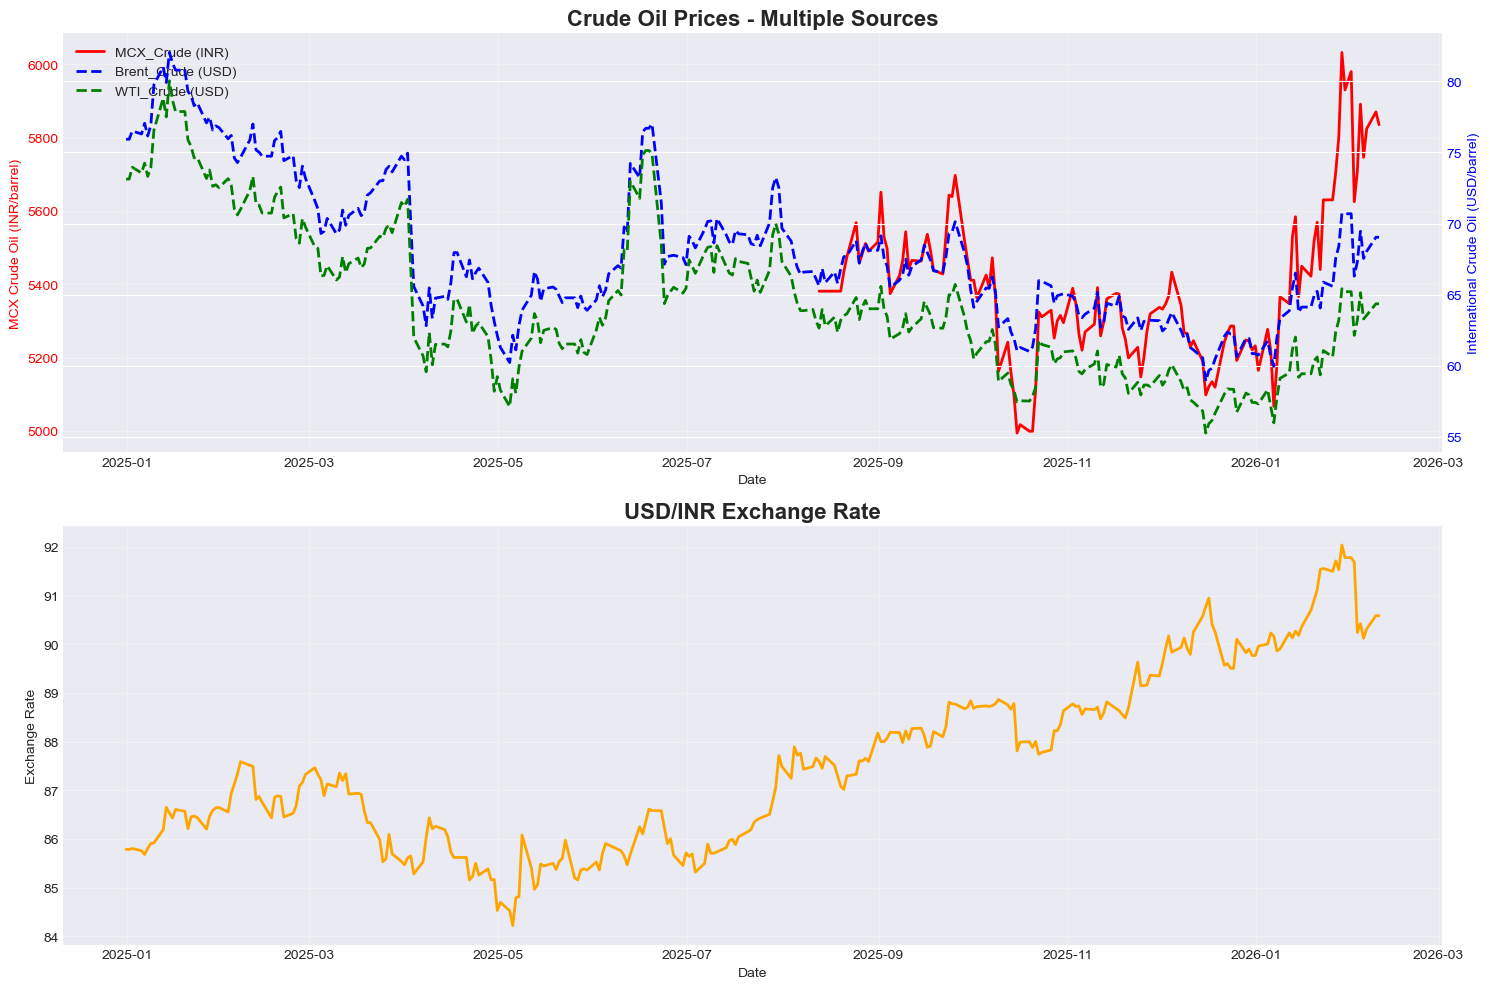

✓ Figure saved as fig_1_crude_oil_prices.png


In [23]:
# Plot crude oil prices (all sources)
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Crude oil prices with dual y-axes
crude_cols = [col for col in master_df.columns if 'Crude' in col or 'crude' in col.lower()]

# Separate MCX (INR) from international prices (USD)
mcx_cols = [col for col in crude_cols if 'MCX' in col]
intl_cols = [col for col in crude_cols if col not in mcx_cols]

# Plot MCX on primary y-axis (left)
for col in mcx_cols:
    axes[0].plot(master_df.index, master_df[col], label=f'{col} (INR)', linewidth=2, color='red')

axes[0].set_xlabel('Date')
axes[0].set_ylabel('MCX Crude Oil (INR/barrel)', color='red')
axes[0].tick_params(axis='y', labelcolor='red')
axes[0].grid(True, alpha=0.3)

# Create secondary y-axis for international prices (USD)
if intl_cols:
    ax_twin = axes[0].twinx()
    colors = ['blue', 'green', 'purple', 'orange']
    for i, col in enumerate(intl_cols):
        ax_twin.plot(master_df.index, master_df[col], label=f'{col} (USD)', 
                     linewidth=2, linestyle='--', color=colors[i % len(colors)])
    
    ax_twin.set_ylabel('International Crude Oil (USD/barrel)', color='blue')
    ax_twin.tick_params(axis='y', labelcolor='blue')

# Combine legends from both axes
lines1, labels1 = axes[0].get_legend_handles_labels()
if intl_cols:
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    axes[0].legend(lines1 + lines2, labels1 + labels2, loc='upper left')
else:
    axes[0].legend(lines1, labels1, loc='upper left')

axes[0].set_title('Crude Oil Prices - Multiple Sources', fontsize=16, fontweight='bold')

# Plot 2: USD/INR exchange rate
if 'USDINR' in master_df.columns:
    axes[1].plot(master_df.index, master_df['USDINR'], color='orange', linewidth=2)
    axes[1].set_title('USD/INR Exchange Rate', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Exchange Rate')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_1_crude_oil_prices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved as fig_1_crude_oil_prices.png")

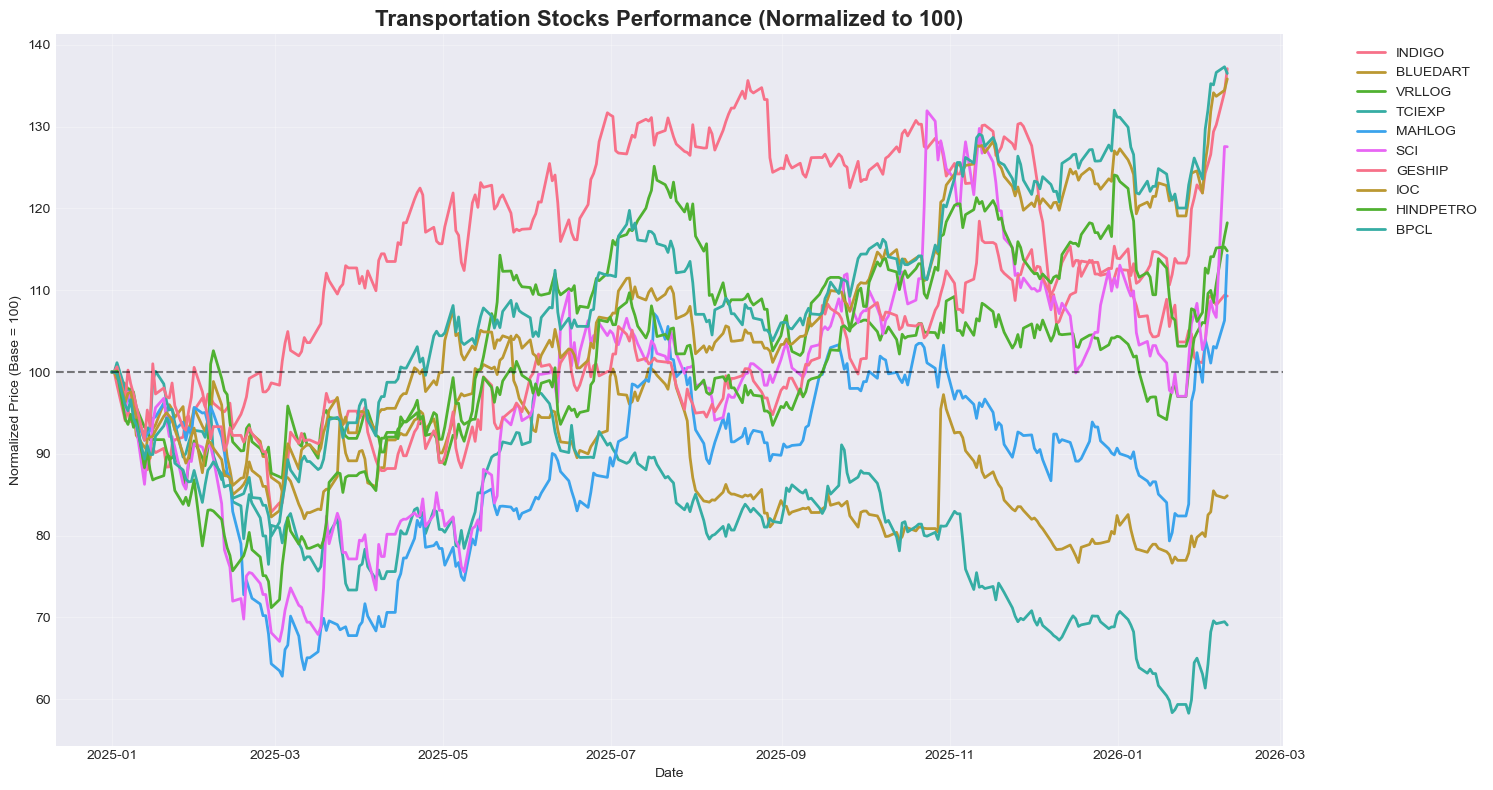

✓ Figure saved as fig_2_transportation_stocks.png


In [20]:
# Plot transportation stocks (normalized to 100 at start)
stock_cols = [col for col in master_df.columns if 'Stock_' in col]

if stock_cols:
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # Normalize prices to start at 100
    for col in stock_cols:
        normalized = (master_df[col] / master_df[col].iloc[0]) * 100
        ax.plot(master_df.index, normalized, label=col.replace('Stock_', ''), linewidth=2)
    
    ax.set_title('Transportation Stocks Performance (Normalized to 100)', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Normalized Price (Base = 100)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=100, color='black', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.savefig('fig_2_transportation_stocks.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved as fig_2_transportation_stocks.png")
else:
    print("No stock data available to plot")

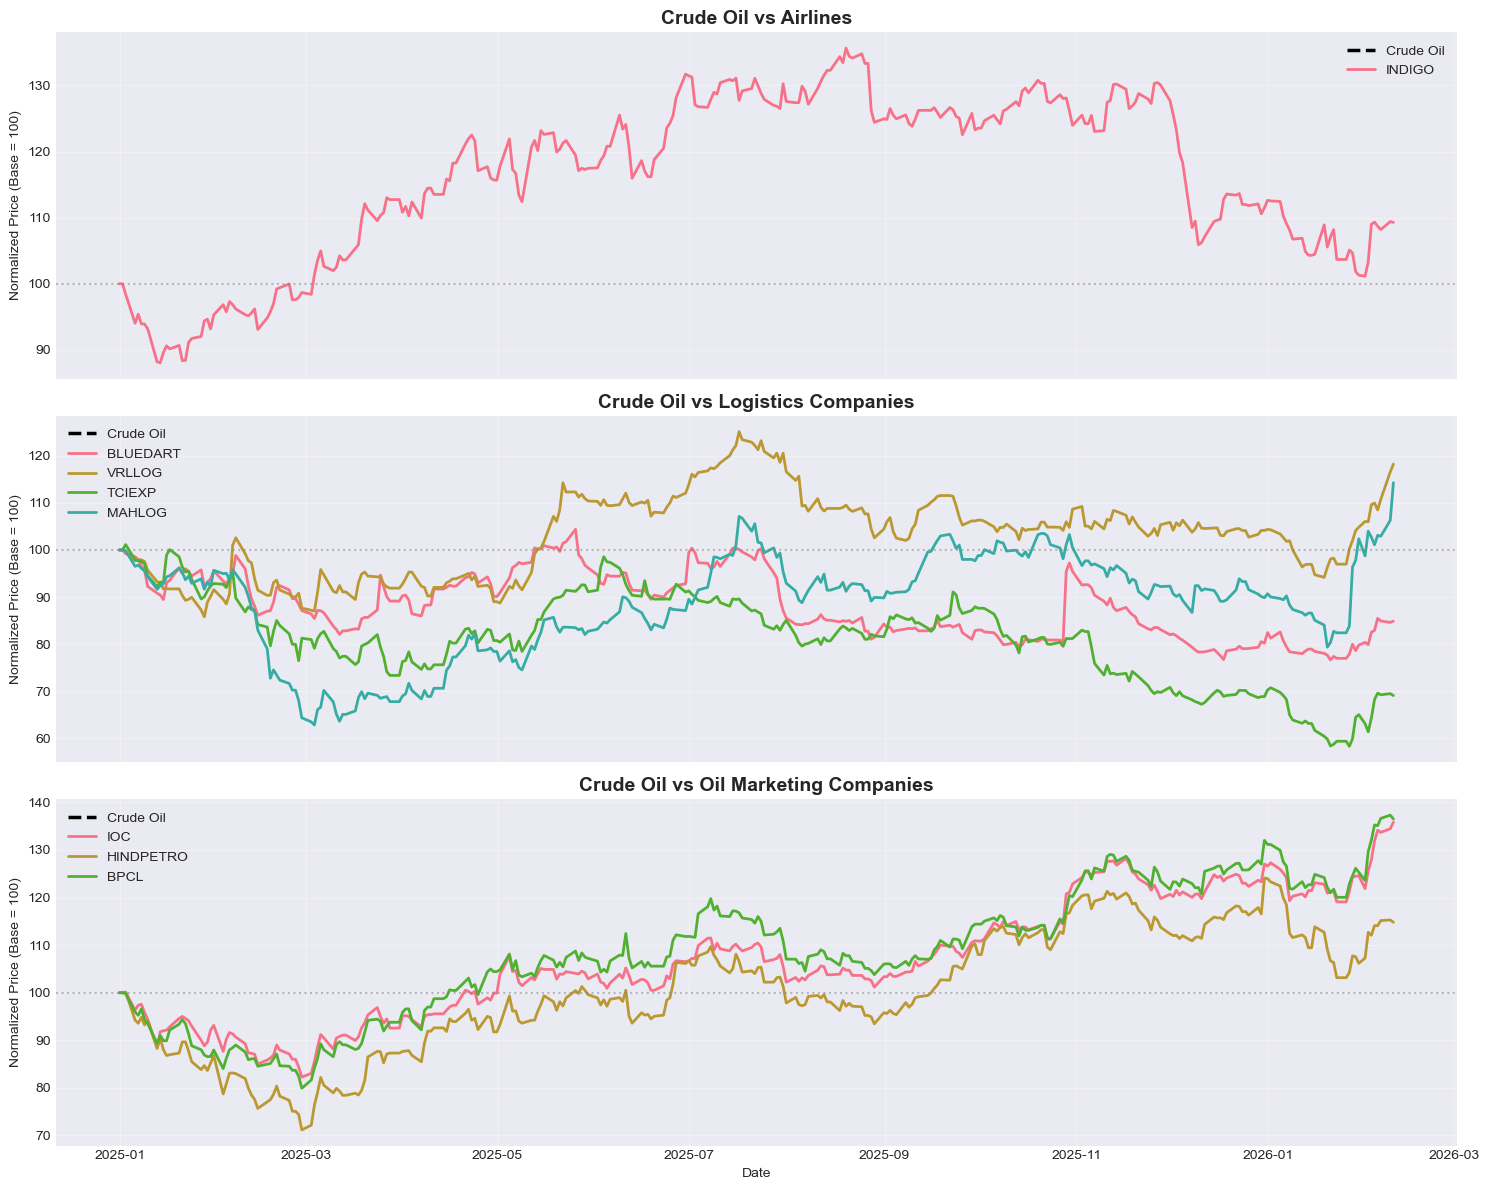

✓ Figure saved as fig_3_crude_vs_sectors.png


In [25]:
# Plot crude oil vs select transportation stocks
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Normalize all to 100
crude_col = 'MCX_Crude' if 'MCX_Crude' in master_df.columns else 'Brent_Crude'

if crude_col in master_df.columns:
    crude_normalized = (master_df[crude_col] / master_df[crude_col].iloc[0]) * 100
    
    # Plot 1: Crude vs Airlines ✅ FIXED
    airline_stocks = [col for col in stock_cols if any(x in col for x in ['INDIGO', 'SPICE', 'JETAIR'])]
    axes[0].plot(master_df.index, crude_normalized, label='Crude Oil', 
                 linewidth=2.5, color='black', linestyle='--')
    
    if airline_stocks:  # Only plot if we have airline stocks
        for col in airline_stocks:
            normalized = (master_df[col] / master_df[col].iloc[0]) * 100
            axes[0].plot(master_df.index, normalized, label=col.replace('Stock_', ''), linewidth=2)
        axes[0].set_title('Crude Oil vs Airlines', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].axhline(y=100, color='gray', linestyle=':', alpha=0.5)
        axes[0].set_ylabel('Normalized Price (Base = 100)')
    else:
        axes[0].text(0.5, 0.5, 'No airline stocks available', 
                    ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
        axes[0].set_title('Crude Oil vs Airlines (No Data)', fontsize=14, fontweight='bold')
    
    # Plot 2: Crude vs Logistics ✅ IMPROVED
    logistics_stocks = [col for col in stock_cols if any(x in col for x in ['BLUE', 'VRL', 'TCI', 'MAH'])]
    axes[1].plot(master_df.index, crude_normalized, label='Crude Oil', 
                 linewidth=2.5, color='black', linestyle='--')
    
    if logistics_stocks:
        for col in logistics_stocks:
            normalized = (master_df[col] / master_df[col].iloc[0]) * 100
            axes[1].plot(master_df.index, normalized, label=col.replace('Stock_', ''), linewidth=2)
        axes[1].set_title('Crude Oil vs Logistics Companies', fontsize=14, fontweight='bold')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(y=100, color='gray', linestyle=':', alpha=0.5)
        axes[1].set_ylabel('Normalized Price (Base = 100)')
    else:
        axes[1].text(0.5, 0.5, 'No logistics stocks available', 
                    ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
        axes[1].set_title('Crude Oil vs Logistics Companies (No Data)', fontsize=14, fontweight='bold')
    
    # Plot 3: Crude vs Oil Marketing Companies ✅ IMPROVED
    omc_stocks = [col for col in stock_cols if any(x in col for x in ['IOC', 'HIND', 'BPCL'])]
    axes[2].plot(master_df.index, crude_normalized, label='Crude Oil', 
                 linewidth=2.5, color='black', linestyle='--')
    
    if omc_stocks:
        for col in omc_stocks:
            normalized = (master_df[col] / master_df[col].iloc[0]) * 100
            axes[2].plot(master_df.index, normalized, label=col.replace('Stock_', ''), linewidth=2)
        axes[2].set_title('Crude Oil vs Oil Marketing Companies', fontsize=14, fontweight='bold')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        axes[2].axhline(y=100, color='gray', linestyle=':', alpha=0.5)
        axes[2].set_ylabel('Normalized Price (Base = 100)')
        axes[2].set_xlabel('Date')
    else:
        axes[2].text(0.5, 0.5, 'No OMC stocks available', 
                    ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
        axes[2].set_title('Crude Oil vs Oil Marketing Companies (No Data)', fontsize=14, fontweight='bold')
        axes[2].set_xlabel('Date')
    
    plt.tight_layout()
    plt.savefig('fig_3_crude_vs_sectors.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved as fig_3_crude_vs_sectors.png")

### 8.2 Correlation Analysis

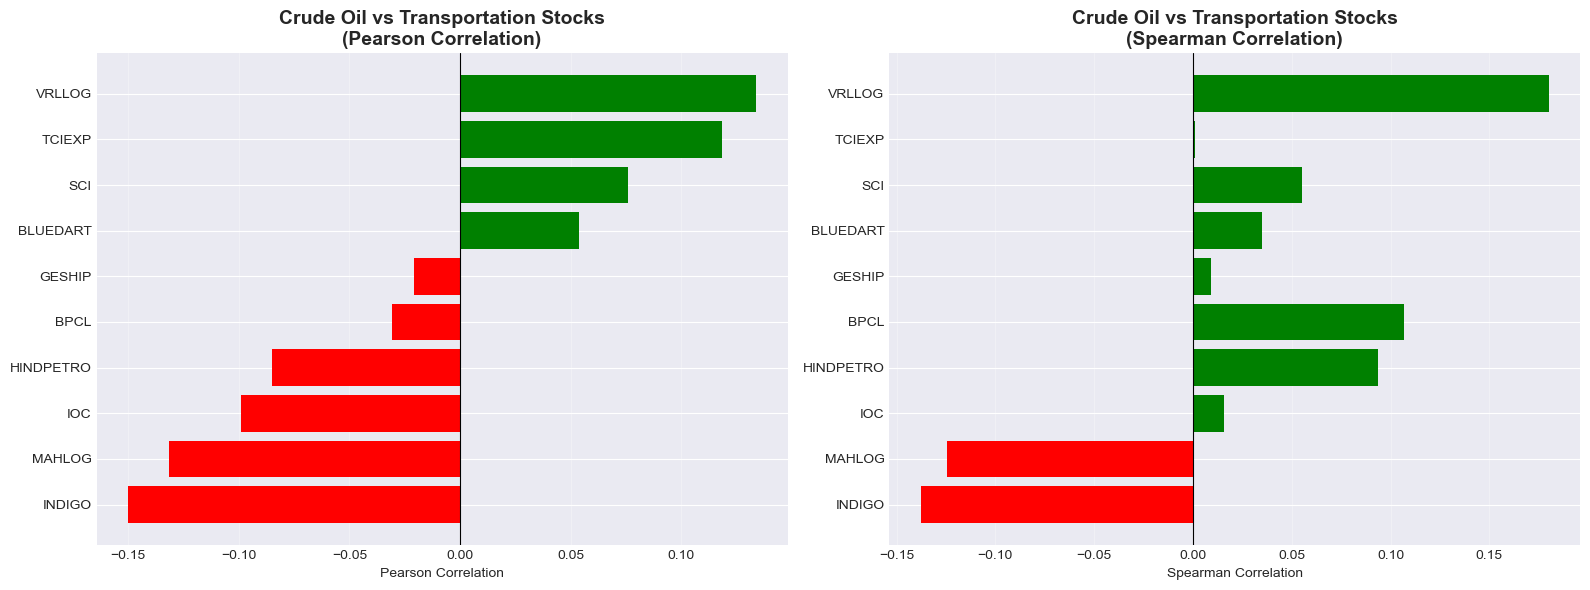

✓ Figure saved as fig_4_correlations.png

Correlation Summary:
    Stock  Pearson  Spearman
   INDIGO  -0.1501   -0.1378
   MAHLOG  -0.1314   -0.1245
      IOC  -0.0992    0.0157
HINDPETRO  -0.0851    0.0939
     BPCL  -0.0309    0.1071
   GESHIP  -0.0207    0.0091
 BLUEDART   0.0536    0.0351
      SCI   0.0758    0.0553
   TCIEXP   0.1183    0.0012
   VRLLOG   0.1339    0.1800


In [26]:
# Correlation matrix - Focus on crude oil vs stocks
crude_return_col = 'MCX_Crude_return' if 'MCX_Crude_return' in returns_df.columns else 'Brent_Crude_return'
stock_return_cols = [col for col in returns_df.columns if 'Stock_' in col]

if crude_return_col in returns_df.columns and stock_return_cols:
    # Calculate correlations
    correlations = []
    
    for col in stock_return_cols:
        corr_pearson = returns_df[crude_return_col].corr(returns_df[col])
        corr_spearman = returns_df[crude_return_col].corr(returns_df[col], method='spearman')
        
        correlations.append({
            'Stock': col.replace('Stock_', '').replace('_return', ''),
            'Pearson': corr_pearson,
            'Spearman': corr_spearman
        })
    
    corr_df = pd.DataFrame(correlations).sort_values('Pearson')
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pearson correlation
    axes[0].barh(corr_df['Stock'], corr_df['Pearson'], color=['red' if x < 0 else 'green' for x in corr_df['Pearson']])
    axes[0].set_xlabel('Pearson Correlation')
    axes[0].set_title('Crude Oil vs Transportation Stocks\n(Pearson Correlation)', 
                      fontsize=14, fontweight='bold')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Spearman correlation
    axes[1].barh(corr_df['Stock'], corr_df['Spearman'], color=['red' if x < 0 else 'green' for x in corr_df['Spearman']])
    axes[1].set_xlabel('Spearman Correlation')
    axes[1].set_title('Crude Oil vs Transportation Stocks\n(Spearman Correlation)', 
                      fontsize=14, fontweight='bold')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('fig_4_correlations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved as fig_4_correlations.png")
    print("\nCorrelation Summary:")
    print(corr_df.to_string(index=False))

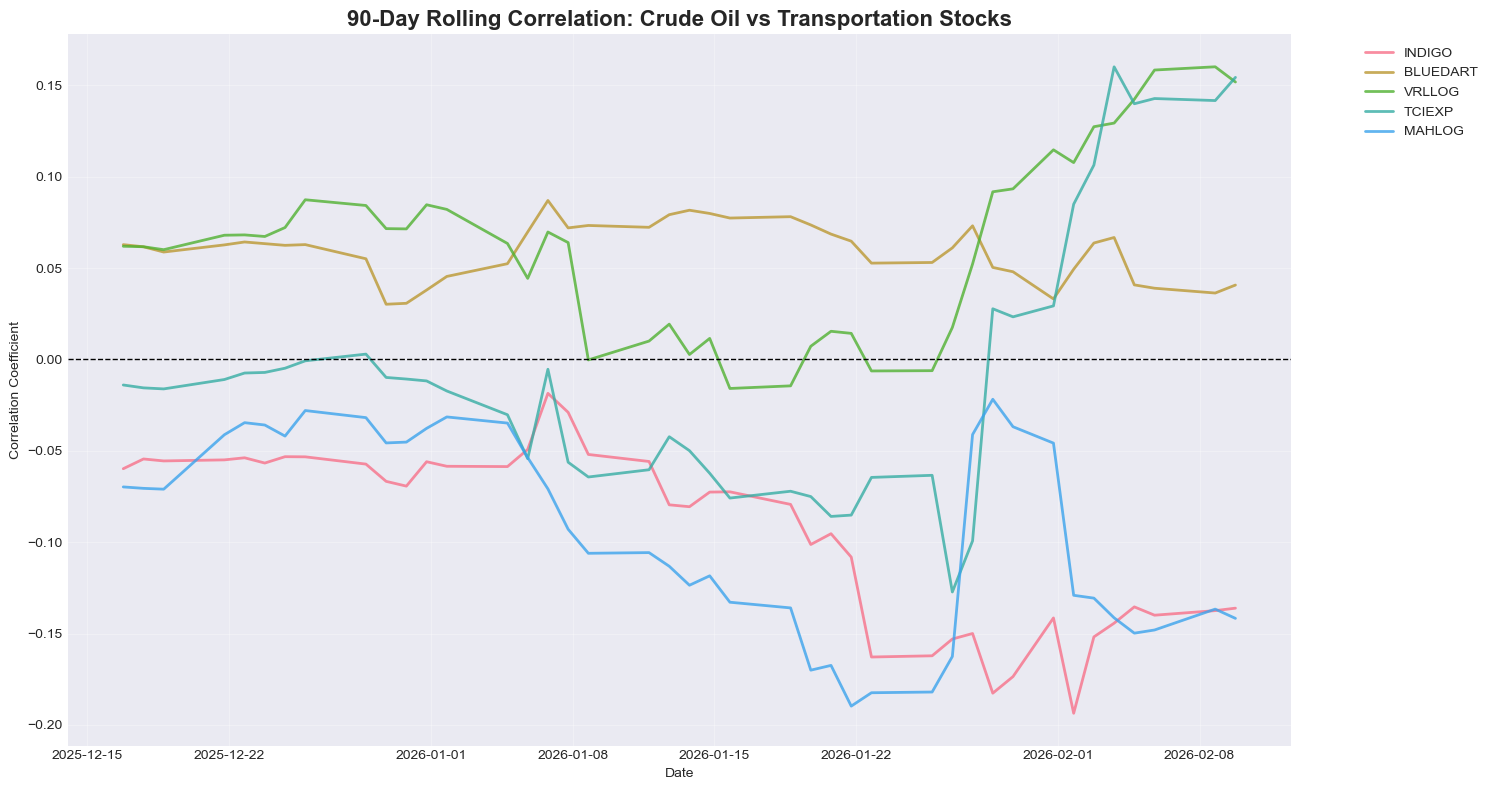

✓ Figure saved as fig_5_rolling_correlation.png


In [27]:
# Rolling correlation analysis (90-day window)
if crude_return_col in returns_df.columns and stock_return_cols:
    fig, ax = plt.subplots(figsize=(15, 8))
    
    window = 90  # 90-day rolling window
    
    for col in stock_return_cols[:5]:  # Plot first 5 stocks for clarity
        rolling_corr = returns_df[crude_return_col].rolling(window=window).corr(returns_df[col])
        ax.plot(returns_df.index, rolling_corr, 
                label=col.replace('Stock_', '').replace('_return', ''), 
                linewidth=2, alpha=0.8)
    
    ax.set_title(f'{window}-Day Rolling Correlation: Crude Oil vs Transportation Stocks', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Correlation Coefficient')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('fig_5_rolling_correlation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved as fig_5_rolling_correlation.png")

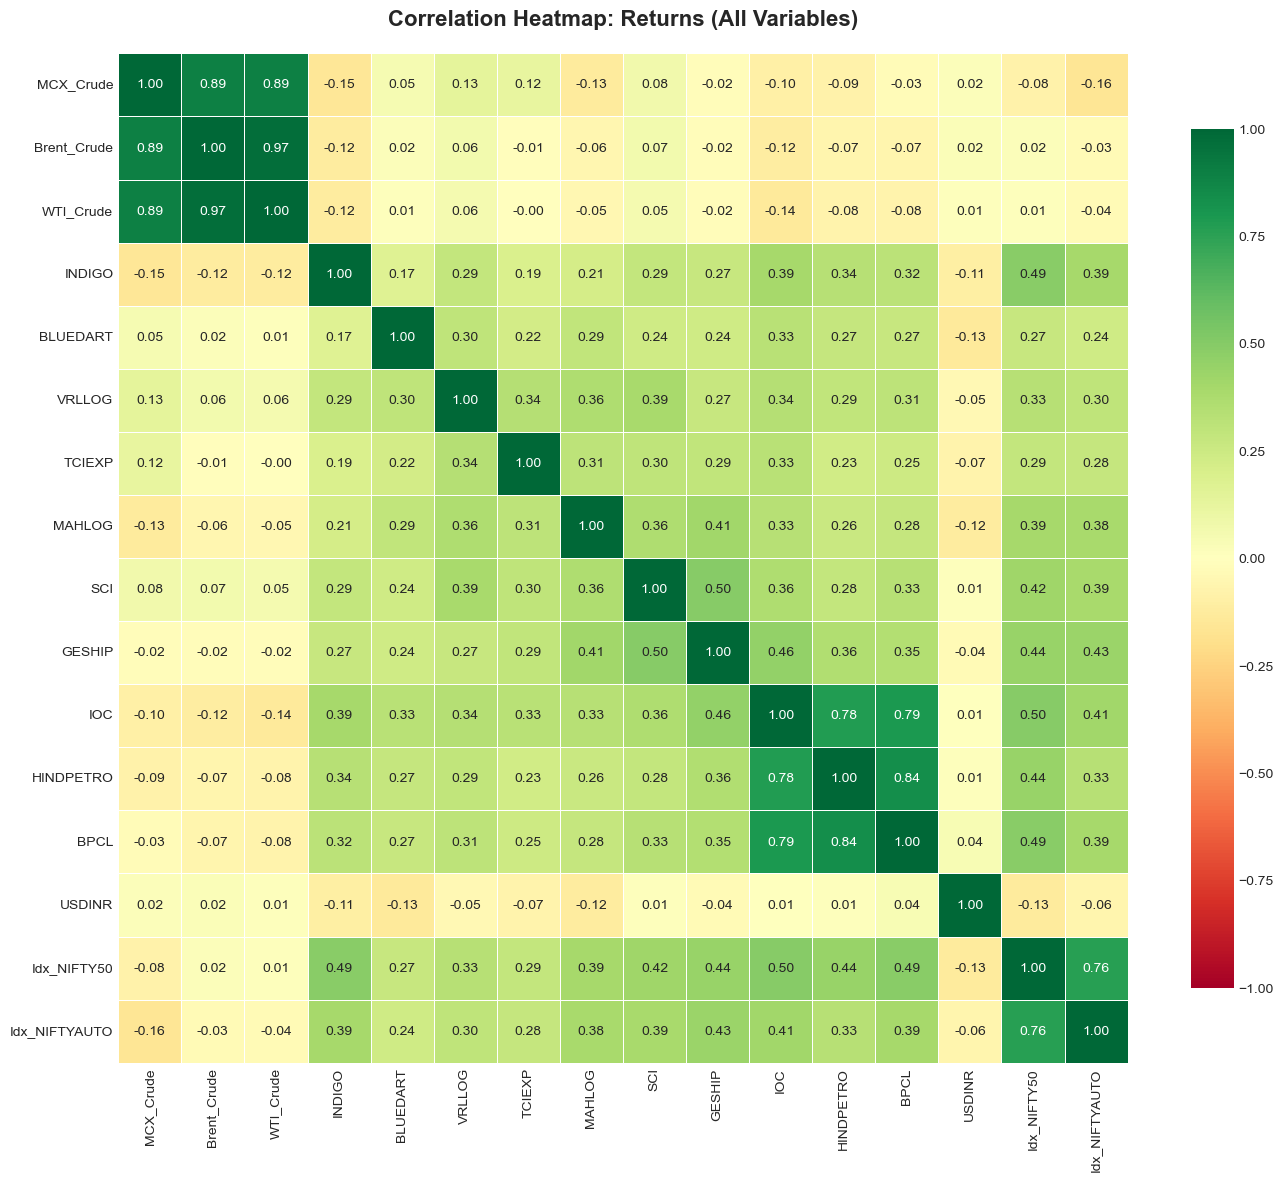

✓ Figure saved as fig_6_correlation_heatmap.png


In [28]:
# Full correlation heatmap
# Select key variables for heatmap
key_cols = []

# Add crude oil columns
key_cols.extend([col for col in returns_df.columns if 'Crude' in col][:3])

# Add stock columns
key_cols.extend([col for col in returns_df.columns if 'Stock_' in col])

# Add USDINR if available
usdinr_col = [col for col in returns_df.columns if 'USDINR' in col]
if usdinr_col:
    key_cols.extend(usdinr_col)

# Add index columns
index_cols = [col for col in returns_df.columns if 'Index_' in col]
key_cols.extend(index_cols[:2])

if key_cols:
    # Calculate correlation matrix
    corr_matrix = returns_df[key_cols].corr()
    
    # Rename columns for better readability
    corr_matrix.columns = [col.replace('_return', '').replace('Stock_', '').replace('Index_', 'Idx_') 
                           for col in corr_matrix.columns]
    corr_matrix.index = corr_matrix.columns
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                vmin=-1, vmax=1, ax=ax)
    
    ax.set_title('Correlation Heatmap: Returns (All Variables)', 
                 fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('fig_6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved as fig_6_correlation_heatmap.png")

### 8.3 Descriptive Statistics by Sub-Sector

In [29]:
# Categorize stocks by sub-sector
def categorize_stock(stock_name):
    if any(x in stock_name for x in ['SPICE', 'JET', 'AIR']):
        return 'Airlines'
    elif any(x in stock_name for x in ['BLUE', 'VRL', 'TCI', 'MAH']):
        return 'Logistics'
    elif any(x in stock_name for x in ['SCI', 'GESHIP', 'SHIP']):
        return 'Shipping'
    elif any(x in stock_name for x in ['IOC', 'HIND', 'BPCL', 'PETRO']):
        return 'Oil Marketing'
    else:
        return 'Other'

# Create sector summary
sector_stats = []

for col in stock_return_cols:
    stock_name = col.replace('Stock_', '').replace('_return', '')
    sector = categorize_stock(stock_name)
    
    stock_returns = returns_df[col].dropna()
    crude_returns = returns_df[crude_return_col].dropna()
    
    # Align indices
    common_idx = stock_returns.index.intersection(crude_returns.index)
    
    if len(common_idx) > 0:
        corr = stock_returns[common_idx].corr(crude_returns[common_idx])
        
        sector_stats.append({
            'Stock': stock_name,
            'Sector': sector,
            'Mean Return': stock_returns.mean(),
            'Std Dev': stock_returns.std(),
            'Sharpe Ratio': stock_returns.mean() / stock_returns.std() * np.sqrt(252),  # Annualized
            'Correlation with Crude': corr
        })

sector_df = pd.DataFrame(sector_stats)

print("Descriptive Statistics by Stock:\n")
print(sector_df.to_string(index=False))

# Summary by sector
print("\n\nAverage Statistics by Sector:\n")
sector_summary = sector_df.groupby('Sector').agg({
    'Mean Return': 'mean',
    'Std Dev': 'mean',
    'Sharpe Ratio': 'mean',
    'Correlation with Crude': 'mean'
}).round(4)

print(sector_summary)

Descriptive Statistics by Stock:

    Stock        Sector  Mean Return  Std Dev  Sharpe Ratio  Correlation with Crude
   INDIGO         Other       0.0003   0.0170        0.2858                 -0.1501
 BLUEDART     Logistics      -0.0006   0.0189       -0.4748                  0.0536
   VRLLOG     Logistics       0.0006   0.0175        0.5249                  0.1339
   TCIEXP     Logistics      -0.0013   0.0202       -1.0023                  0.1183
   MAHLOG     Logistics       0.0005   0.0227        0.3219                 -0.1314
      SCI      Shipping       0.0008   0.0289        0.4602                  0.0758
   GESHIP      Shipping       0.0011   0.0192        0.9019                 -0.0207
      IOC Oil Marketing       0.0011   0.0150        1.1179                 -0.0992
HINDPETRO Oil Marketing       0.0005   0.0196        0.3865                 -0.0851
     BPCL Oil Marketing       0.0011   0.0161        1.0587                 -0.0309


Average Statistics by Sector:

         

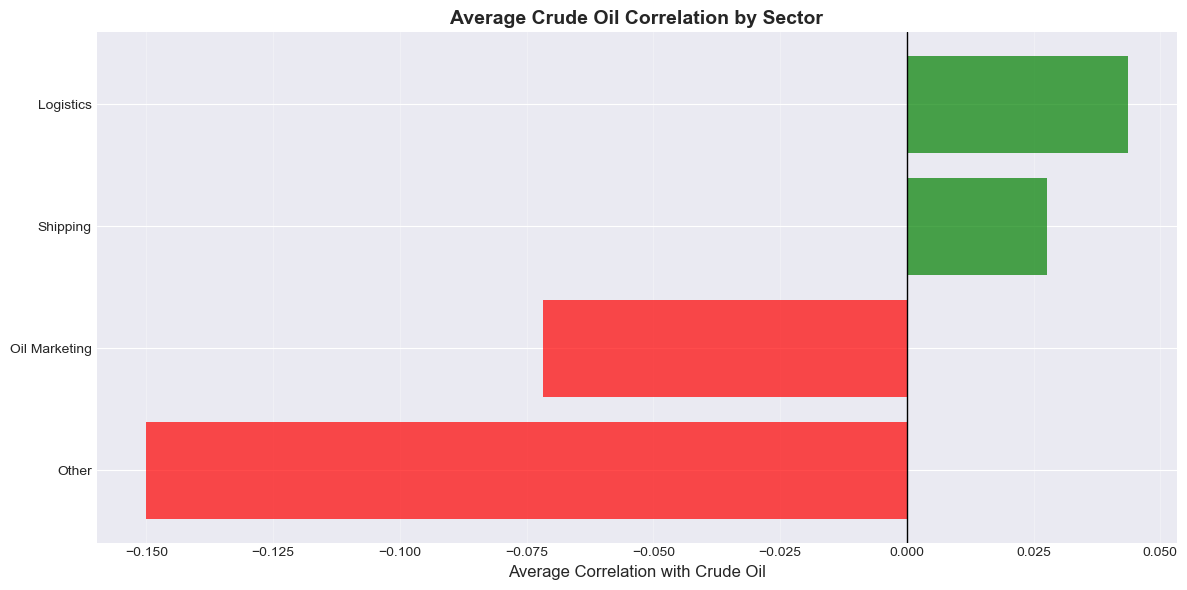

✓ Figure saved as fig_7_sector_correlation.png


In [30]:
# Visualize sector-wise correlation
fig, ax = plt.subplots(figsize=(12, 6))

sector_summary_sorted = sector_summary.sort_values('Correlation with Crude')
colors = ['red' if x < 0 else 'green' for x in sector_summary_sorted['Correlation with Crude']]

ax.barh(sector_summary_sorted.index, sector_summary_sorted['Correlation with Crude'], color=colors, alpha=0.7)
ax.set_xlabel('Average Correlation with Crude Oil', fontsize=12)
ax.set_title('Average Crude Oil Correlation by Sector', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig_7_sector_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure saved as fig_7_sector_correlation.png")

## 9. Statistical Testing

### 9.1 Stationarity Tests (Augmented Dickey-Fuller)

In [31]:
# Test stationarity of returns using ADF test
def adf_test(series, name):
    """
    Perform Augmented Dickey-Fuller test
    H0: Series has unit root (non-stationary)
    H1: Series is stationary
    """
    result = adfuller(series.dropna(), autolag='AIC')
    
    return {
        'Variable': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Value (5%)': result[4]['5%'],
        'Stationary': 'Yes' if result[1] < 0.05 else 'No'
    }

print("Testing Stationarity of Returns (ADF Test)\n")
print("H0: Series has unit root (non-stationary)")
print("H1: Series is stationary (reject H0 if p-value < 0.05)\n")

adf_results = []

# Test crude oil
if crude_return_col in returns_df.columns:
    adf_results.append(adf_test(returns_df[crude_return_col], 'Crude Oil'))

# Test all stocks
for col in stock_return_cols:
    stock_name = col.replace('Stock_', '').replace('_return', '')
    adf_results.append(adf_test(returns_df[col], stock_name))

adf_df = pd.DataFrame(adf_results)
print(adf_df.to_string(index=False))

print(f"\n\nSummary: {adf_df['Stationary'].value_counts()['Yes']}/{len(adf_df)} series are stationary")
print("(All return series should be stationary for proper analysis)")

Testing Stationarity of Returns (ADF Test)

H0: Series has unit root (non-stationary)
H1: Series is stationary (reject H0 if p-value < 0.05)

 Variable  ADF Statistic  p-value  Critical Value (5%) Stationary
Crude Oil       -12.8043   0.0000              -2.8842        Yes
   INDIGO       -16.8820   0.0000              -2.8716        Yes
 BLUEDART       -15.1572   0.0000              -2.8716        Yes
   VRLLOG        -6.4271   0.0000              -2.8718        Yes
   TCIEXP       -12.7318   0.0000              -2.8716        Yes
   MAHLOG        -4.4287   0.0003              -2.8720        Yes
      SCI        -4.1452   0.0008              -2.8720        Yes
   GESHIP        -5.9724   0.0000              -2.8719        Yes
      IOC       -16.9944   0.0000              -2.8716        Yes
HINDPETRO       -16.8240   0.0000              -2.8716        Yes
     BPCL       -17.6122   0.0000              -2.8716        Yes


Summary: 11/11 series are stationary
(All return series should b

### 9.2 Granger Causality Test

Test whether crude oil returns "Granger-cause" transportation stock returns.

In [32]:
# Granger Causality Test
def granger_test(data, x_col, y_col, max_lag=5):
    """
    Test if x Granger-causes y
    H0: x does NOT Granger-cause y
    H1: x Granger-causes y
    """
    # Prepare data
    test_data = data[[y_col, x_col]].dropna()
    
    if len(test_data) < 50:
        return None
    
    try:
        # Run Granger causality test
        gc_result = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
        
        # Extract p-values for each lag
        p_values = []
        for lag in range(1, max_lag + 1):
            p_value = gc_result[lag][0]['ssr_ftest'][1]
            p_values.append(p_value)
        
        # Find minimum p-value and corresponding lag
        min_p_value = min(p_values)
        optimal_lag = p_values.index(min_p_value) + 1
        
        return {
            'X': x_col.replace('_return', ''),
            'Y': y_col.replace('Stock_', '').replace('_return', ''),
            'Optimal Lag': optimal_lag,
            'p-value': min_p_value,
            'Granger Causes': 'Yes' if min_p_value < 0.05 else 'No'
        }
    except Exception as e:
        print(f"Error testing {x_col} -> {y_col}: {e}")
        return None

print("Granger Causality Test: Does Crude Oil cause Transportation Stocks?\n")
print("H0: Crude Oil does NOT Granger-cause Stock Returns")
print("H1: Crude Oil Granger-causes Stock Returns (reject H0 if p-value < 0.05)\n")

granger_results = []

for stock_col in stock_return_cols:
    result = granger_test(returns_df, crude_return_col, stock_col, max_lag=10)
    if result:
        granger_results.append(result)

granger_df = pd.DataFrame(granger_results)

if not granger_df.empty:
    granger_df = granger_df.sort_values('p-value')
    print(granger_df.to_string(index=False))
    
    print(f"\n\nSummary:")
    print(f"Crude Oil Granger-causes {granger_df['Granger Causes'].value_counts().get('Yes', 0)}/{len(granger_df)} stocks at 5% significance")
else:
    print("No valid Granger causality tests completed")

Granger Causality Test: Does Crude Oil cause Transportation Stocks?

H0: Crude Oil does NOT Granger-cause Stock Returns
H1: Crude Oil Granger-causes Stock Returns (reject H0 if p-value < 0.05)

        X         Y  Optimal Lag  p-value Granger Causes
MCX_Crude    VRLLOG            2   0.0318            Yes
MCX_Crude    MAHLOG            1   0.0425            Yes
MCX_Crude       SCI            1   0.0498            Yes
MCX_Crude    INDIGO            1   0.0895             No
MCX_Crude      BPCL            9   0.1533             No
MCX_Crude  BLUEDART            5   0.1615             No
MCX_Crude HINDPETRO            1   0.2457             No
MCX_Crude       IOC            9   0.3601             No
MCX_Crude    TCIEXP           10   0.3959             No
MCX_Crude    GESHIP            1   0.5635             No


Summary:
Crude Oil Granger-causes 3/10 stocks at 5% significance


In [33]:
# Test reverse causality (Do stocks cause crude?)
print("\n" + "="*80)
print("Reverse Granger Causality Test: Do Transportation Stocks cause Crude Oil?\n")

reverse_granger_results = []

for stock_col in stock_return_cols:
    result = granger_test(returns_df, stock_col, crude_return_col, max_lag=10)
    if result:
        reverse_granger_results.append(result)

reverse_granger_df = pd.DataFrame(reverse_granger_results)

if not reverse_granger_df.empty:
    reverse_granger_df = reverse_granger_df.sort_values('p-value')
    print(reverse_granger_df.to_string(index=False))
    
    print(f"\n\nSummary:")
    print(f"{reverse_granger_df['Granger Causes'].value_counts().get('Yes', 0)}/{len(reverse_granger_df)} stocks Granger-cause Crude Oil at 5% significance")
    print("\n(Reverse causality is not expected but worth checking)")


Reverse Granger Causality Test: Do Transportation Stocks cause Crude Oil?

              X         Y  Optimal Lag  p-value Granger Causes
Stock_HINDPETRO MCX_Crude            4   0.0037            Yes
   Stock_MAHLOG MCX_Crude            1   0.0147            Yes
      Stock_IOC MCX_Crude            4   0.0572             No
   Stock_GESHIP MCX_Crude            1   0.0910             No
      Stock_SCI MCX_Crude            3   0.0961             No
 Stock_BLUEDART MCX_Crude            1   0.1475             No
     Stock_BPCL MCX_Crude            8   0.1485             No
   Stock_INDIGO MCX_Crude            1   0.3034             No
   Stock_VRLLOG MCX_Crude            1   0.4622             No
   Stock_TCIEXP MCX_Crude            7   0.4759             No


Summary:
2/10 stocks Granger-cause Crude Oil at 5% significance

(Reverse causality is not expected but worth checking)


### 9.3 Cointegration Test

Test for long-run equilibrium relationship between crude oil and transportation stocks.

In [34]:
# Cointegration Test (Engle-Granger)
crude_price_col = 'MCX_Crude' if 'MCX_Crude' in master_df.columns else 'Brent_Crude'

def cointegration_test(data, x_col, y_col):
    """
    Test for cointegration between two price series
    H0: No cointegration
    H1: Series are cointegrated
    """
    # Prepare data
    test_data = data[[x_col, y_col]].dropna()
    
    if len(test_data) < 50:
        return None
    
    try:
        # Engle-Granger cointegration test
        score, pvalue, _ = coint(test_data[x_col], test_data[y_col])
        
        return {
            'Stock': y_col.replace('Stock_', ''),
            'Test Statistic': score,
            'p-value': pvalue,
            'Cointegrated': 'Yes' if pvalue < 0.05 else 'No'
        }
    except Exception as e:
        print(f"Error testing {x_col} with {y_col}: {e}")
        return None

print("Cointegration Test: Crude Oil vs Transportation Stocks (Price Levels)\n")
print("H0: No cointegration (no long-run equilibrium)")
print("H1: Series are cointegrated (reject H0 if p-value < 0.05)\n")

coint_results = []

stock_price_cols = [col for col in master_df.columns if 'Stock_' in col]

for stock_col in stock_price_cols:
    result = cointegration_test(master_df, crude_price_col, stock_col)
    if result:
        coint_results.append(result)

coint_df = pd.DataFrame(coint_results)

if not coint_df.empty:
    coint_df = coint_df.sort_values('p-value')
    print(coint_df.to_string(index=False))
    
    print(f"\n\nSummary:")
    print(f"{coint_df['Cointegrated'].value_counts().get('Yes', 0)}/{len(coint_df)} stocks are cointegrated with Crude Oil at 5% significance")
    print("\n(Cointegration suggests a long-run equilibrium relationship)")
else:
    print("No valid cointegration tests completed")

Cointegration Test: Crude Oil vs Transportation Stocks (Price Levels)

H0: No cointegration (no long-run equilibrium)
H1: Series are cointegrated (reject H0 if p-value < 0.05)

    Stock  Test Statistic  p-value Cointegrated
   VRLLOG         -2.3292   0.3591           No
   INDIGO         -2.2668   0.3902           No
HINDPETRO         -2.1931   0.4279           No
   TCIEXP         -2.0988   0.4770           No
 BLUEDART         -2.0428   0.5063           No
     BPCL         -2.0313   0.5123           No
      IOC         -2.0057   0.5256           No
      SCI         -1.9835   0.5372           No
   MAHLOG         -1.8592   0.6005           No
   GESHIP         -1.5731   0.7321           No


Summary:
0/10 stocks are cointegrated with Crude Oil at 5% significance

(Cointegration suggests a long-run equilibrium relationship)


## 10. Regression Analysis

### 10.1 Basic OLS Regression Model

**Model**: Stock Return = α + β₁(Oil Return) + β₂(Market Return) + β₃(USD/INR Change) + ε

In [35]:
# Prepare independent variables
market_return_col = 'Index_NIFTY50_return' if 'Index_NIFTY50_return' in returns_df.columns else None
usdinr_return_col = 'USDINR_return' if 'USDINR_return' in returns_df.columns else None

def run_ols_regression(returns_df, dependent_var, crude_col, market_col=None, fx_col=None):
    """
    Run OLS regression for stock returns
    """
    # Prepare data
    data = returns_df[[dependent_var, crude_col]].copy()
    
    # Add market return if available
    if market_col and market_col in returns_df.columns:
        data['market'] = returns_df[market_col]
    
    # Add FX return if available
    if fx_col and fx_col in returns_df.columns:
        data['fx'] = returns_df[fx_col]
    
    # Drop NaN
    data = data.dropna()
    
    if len(data) < 30:
        return None
    
    # Dependent variable
    y = data[dependent_var]
    
    # Independent variables
    X = data.drop(columns=[dependent_var])
    X = add_constant(X)
    
    # Run regression
    model = OLS(y, X).fit()
    
    return model

print("OLS Regression Analysis\n")
print("Model: Stock Return = α + β₁(Crude Oil Return) + β₂(Market Return) + β₃(USD/INR Return) + ε\n")

regression_results = []

for stock_col in stock_return_cols:
    stock_name = stock_col.replace('Stock_', '').replace('_return', '')
    
    # Run regression
    model = run_ols_regression(
        returns_df, 
        stock_col, 
        crude_return_col,
        market_return_col,
        usdinr_return_col
    )
    
    if model:
        # Extract coefficients
        beta_crude = model.params.get(crude_return_col, np.nan)
        pval_crude = model.pvalues.get(crude_return_col, np.nan)
        
        beta_market = model.params.get('market', np.nan) if market_return_col else np.nan
        pval_market = model.pvalues.get('market', np.nan) if market_return_col else np.nan
        
        beta_fx = model.params.get('fx', np.nan) if usdinr_return_col else np.nan
        pval_fx = model.pvalues.get('fx', np.nan) if usdinr_return_col else np.nan
        
        regression_results.append({
            'Stock': stock_name,
            'Alpha': model.params['const'],
            'Beta_Crude': beta_crude,
            'p-val_Crude': pval_crude,
            'Sig_Crude': '***' if pval_crude < 0.01 else '**' if pval_crude < 0.05 else '*' if pval_crude < 0.1 else '',
            'Beta_Market': beta_market,
            'p-val_Market': pval_market,
            'Beta_FX': beta_fx,
            'p-val_FX': pval_fx,
            'R-squared': model.rsquared,
            'Adj R-squared': model.rsquared_adj
        })

regression_df = pd.DataFrame(regression_results)

if not regression_df.empty:
    print(regression_df.to_string(index=False))
    
    print("\n\nSignificance levels: *** p<0.01, ** p<0.05, * p<0.1")
    print(f"\nAverage R-squared: {regression_df['R-squared'].mean():.4f}")
    print(f"Average Crude Oil Beta: {regression_df['Beta_Crude'].mean():.4f}")
else:
    print("No valid regression results")

OLS Regression Analysis

Model: Stock Return = α + β₁(Crude Oil Return) + β₂(Market Return) + β₃(USD/INR Return) + ε

    Stock   Alpha  Beta_Crude  p-val_Crude Sig_Crude  Beta_Market  p-val_Market  Beta_FX  p-val_FX  R-squared  Adj R-squared
   INDIGO -0.0019     -0.1114       0.1557                 1.4277        0.0000  -0.1041    0.8092     0.2717         0.2544
 BLUEDART -0.0002      0.0886       0.3886                 0.7408        0.0164  -0.7173    0.2061     0.0797         0.0578
   VRLLOG  0.0002      0.1443       0.0530         *       0.8798        0.0001   0.0986    0.8091     0.1357         0.1151
   TCIEXP -0.0019      0.1731       0.0823         *       1.1867        0.0001   0.3996    0.4648     0.1288         0.1081
   MAHLOG  0.0011     -0.1505       0.2078                 1.1457        0.0015  -0.2710    0.6799     0.1078         0.0865
      SCI  0.0010      0.1782       0.2107                 1.8199        0.0000   0.9632    0.2197     0.1341         0.1135
   GESH

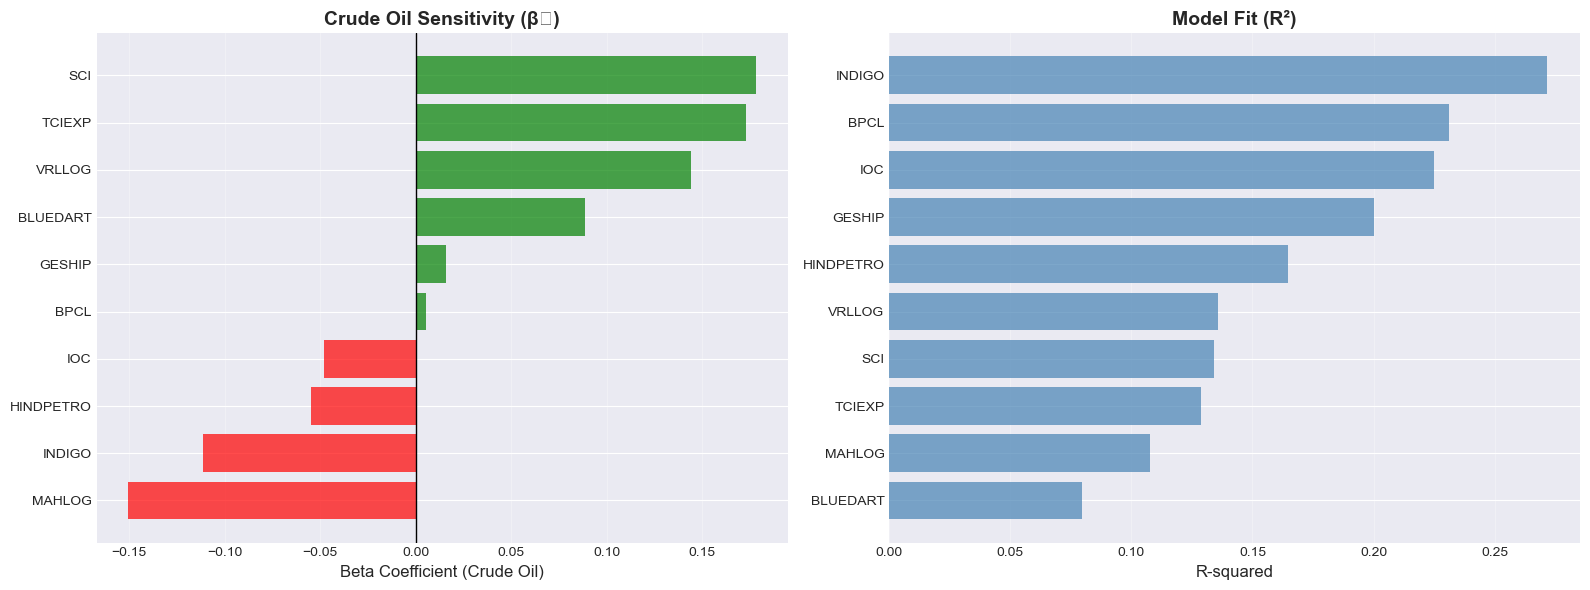

✓ Figure saved as fig_8_regression_coefficients.png


In [36]:
# Visualize regression coefficients
if not regression_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot Beta_Crude
    regression_df_sorted = regression_df.sort_values('Beta_Crude')
    colors = ['red' if x < 0 else 'green' for x in regression_df_sorted['Beta_Crude']]
    
    axes[0].barh(regression_df_sorted['Stock'], regression_df_sorted['Beta_Crude'], 
                 color=colors, alpha=0.7)
    axes[0].set_xlabel('Beta Coefficient (Crude Oil)', fontsize=12)
    axes[0].set_title('Crude Oil Sensitivity (β₁)', fontsize=14, fontweight='bold')
    axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[0].grid(True, alpha=0.3, axis='x')
    
    # Plot R-squared
    regression_df_sorted_r2 = regression_df.sort_values('R-squared')
    axes[1].barh(regression_df_sorted_r2['Stock'], regression_df_sorted_r2['R-squared'], 
                 color='steelblue', alpha=0.7)
    axes[1].set_xlabel('R-squared', fontsize=12)
    axes[1].set_title('Model Fit (R²)', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.savefig('fig_8_regression_coefficients.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Figure saved as fig_8_regression_coefficients.png")

### 10.2 Lagged Regression Analysis

Test if oil price changes lead stock price movements (do past oil returns predict current stock returns?).

In [37]:
# Test lagged relationships
def run_lagged_regression(returns_df, dependent_var, crude_col, max_lag=5):
    """
    Run regression with lagged crude oil returns
    """
    results = []
    
    for lag in range(0, max_lag + 1):
        # Prepare data
        data = pd.DataFrame({
            'stock': returns_df[dependent_var],
            'crude_lag': returns_df[crude_col].shift(lag)
        }).dropna()
        
        if len(data) < 30:
            continue
        
        # Run regression
        y = data['stock']
        X = add_constant(data['crude_lag'])
        
        model = OLS(y, X).fit()
        
        results.append({
            'Lag': lag,
            'Beta': model.params['crude_lag'],
            'p-value': model.pvalues['crude_lag'],
            'R-squared': model.rsquared
        })
    
    return pd.DataFrame(results)

print("Lagged Regression Analysis\n")
print("Testing if past crude oil returns predict current stock returns\n")

# Pick a few representative stocks
representative_stocks = stock_return_cols[:3]

for stock_col in representative_stocks:
    stock_name = stock_col.replace('Stock_', '').replace('_return', '')
    print(f"\n{stock_name}:")
    print("-" * 60)
    
    lag_results = run_lagged_regression(returns_df, stock_col, crude_return_col, max_lag=10)
    print(lag_results.to_string(index=False))
    
    # Find optimal lag
    if not lag_results.empty:
        optimal = lag_results.loc[lag_results['R-squared'].idxmax()]
        print(f"\nOptimal lag: {int(optimal['Lag'])} days (R² = {optimal['R-squared']:.4f})")

Lagged Regression Analysis

Testing if past crude oil returns predict current stock returns


INDIGO:
------------------------------------------------------------
 Lag    Beta  p-value  R-squared
   0 -0.1535   0.0883     0.0225
   1 -0.1534   0.0897     0.0225
   2 -0.0741   0.4166     0.0052
   3 -0.0437   0.6332     0.0018
   4  0.0012   0.9893     0.0000
   5 -0.0897   0.3399     0.0074
   6  0.0367   0.6986     0.0012
   7 -0.0299   0.7682     0.0007
   8 -0.0252   0.8045     0.0005
   9  0.1329   0.1950     0.0141
  10  0.0790   0.4563     0.0047

Optimal lag: 0 days (R² = 0.0225)

BLUEDART:
------------------------------------------------------------
 Lag    Beta  p-value  R-squared
   0  0.0640   0.5446     0.0029
   1 -0.0939   0.3759     0.0062
   2  0.0677   0.5257     0.0032
   3 -0.1235   0.2487     0.0106
   4  0.1978   0.0674     0.0267
   5  0.1808   0.1013     0.0217
   6  0.0975   0.3823     0.0063
   7 -0.0296   0.8049     0.0005
   8  0.0184   0.8780     0.0002
   9

## 11. Event Study Analysis

Analyze stock responses to major crude oil price shocks.

Major Crude Oil Price Shocks (Single Day > 5%)

Found 1 shock events

                     Date  Return Direction
2026-02-01 18:30:00+00:00 -6.1200  Decrease


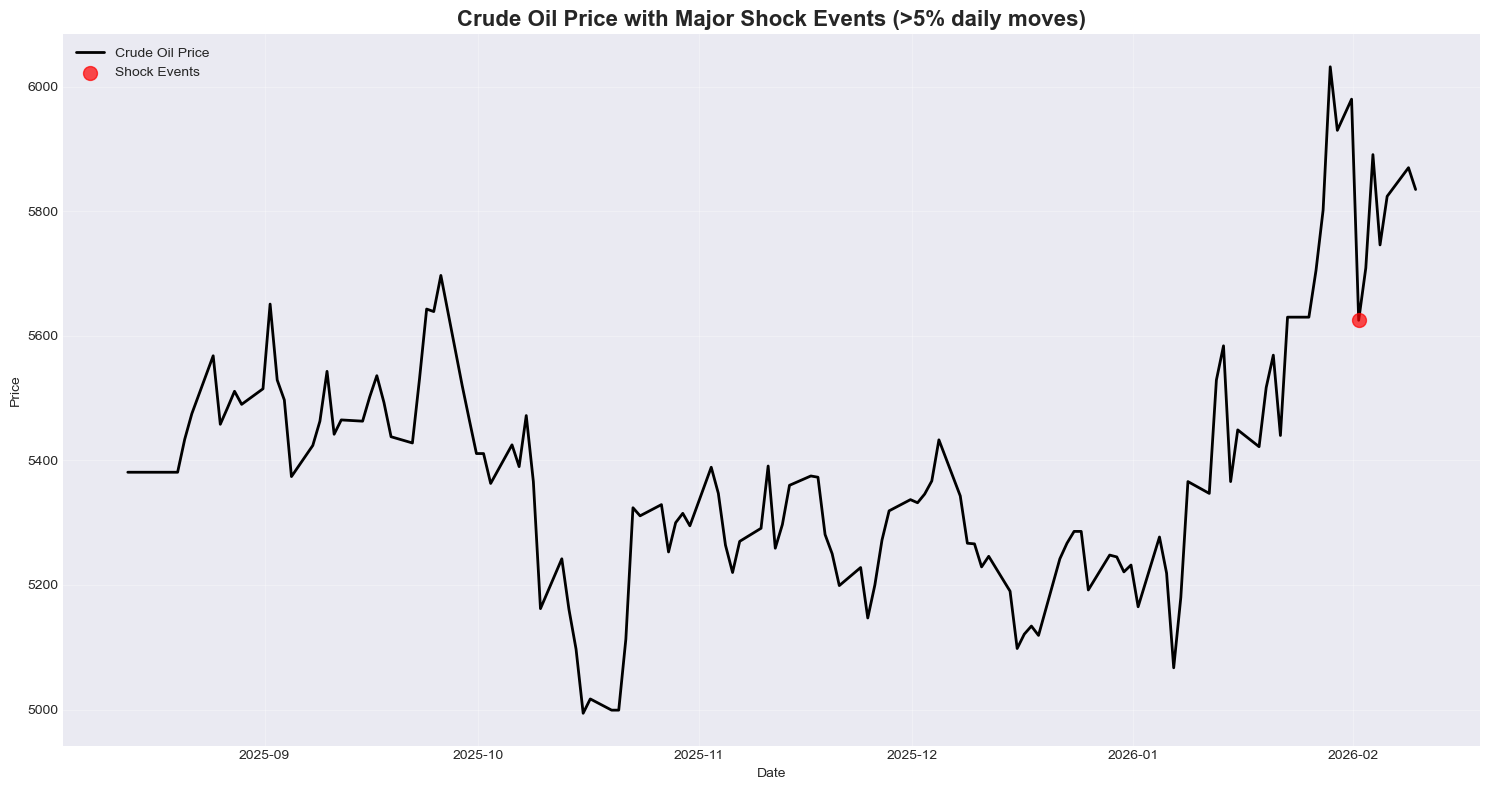


✓ Figure saved as fig_9_oil_shocks.png


In [38]:
# Identify major oil shocks (>10% single-day moves or >15% over 5 days)
crude_returns = returns_df[crude_return_col].dropna()

# Single-day shocks
threshold_1day = 0.05  # 5% daily move
shocks_1day = crude_returns[abs(crude_returns) > threshold_1day]

print("Major Crude Oil Price Shocks (Single Day > 5%)\n")
print(f"Found {len(shocks_1day)} shock events\n")

if len(shocks_1day) > 0:
    shock_summary = pd.DataFrame({
        'Date': shocks_1day.index,
        'Return': shocks_1day.values * 100,  # Convert to percentage
        'Direction': ['Increase' if x > 0 else 'Decrease' for x in shocks_1day.values]
    })
    
    print(shock_summary.to_string(index=False))
    
    # Plot shocks on crude price chart
    fig, ax = plt.subplots(figsize=(15, 8))
    
    ax.plot(master_df.index, master_df[crude_price_col], 
            label='Crude Oil Price', linewidth=2, color='black')
    
    # Mark shock events
    shock_prices = master_df.loc[shocks_1day.index, crude_price_col]
    ax.scatter(shocks_1day.index, shock_prices, 
              color='red', s=100, zorder=5, label='Shock Events', alpha=0.7)
    
    ax.set_title('Crude Oil Price with Major Shock Events (>5% daily moves)', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('fig_9_oil_shocks.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Figure saved as fig_9_oil_shocks.png")
else:
    print("No major single-day shocks found in the period")



Cumulative Abnormal Returns (CAR) Analysis

Event window: -5 to +5 days around shock

Analyzing top 3 shocks:
  1. 2026-02-01: -6.12% return

Average CAR by Stock (across top 3 shock events):

Stock
INDIGO      0.0216
BLUEDART    0.0623
HINDPETRO   0.0791
IOC         0.0892
BPCL        0.1023
TCIEXP      0.1253
GESHIP      0.1370
VRLLOG      0.1518
MAHLOG      0.2227
SCI         0.2415


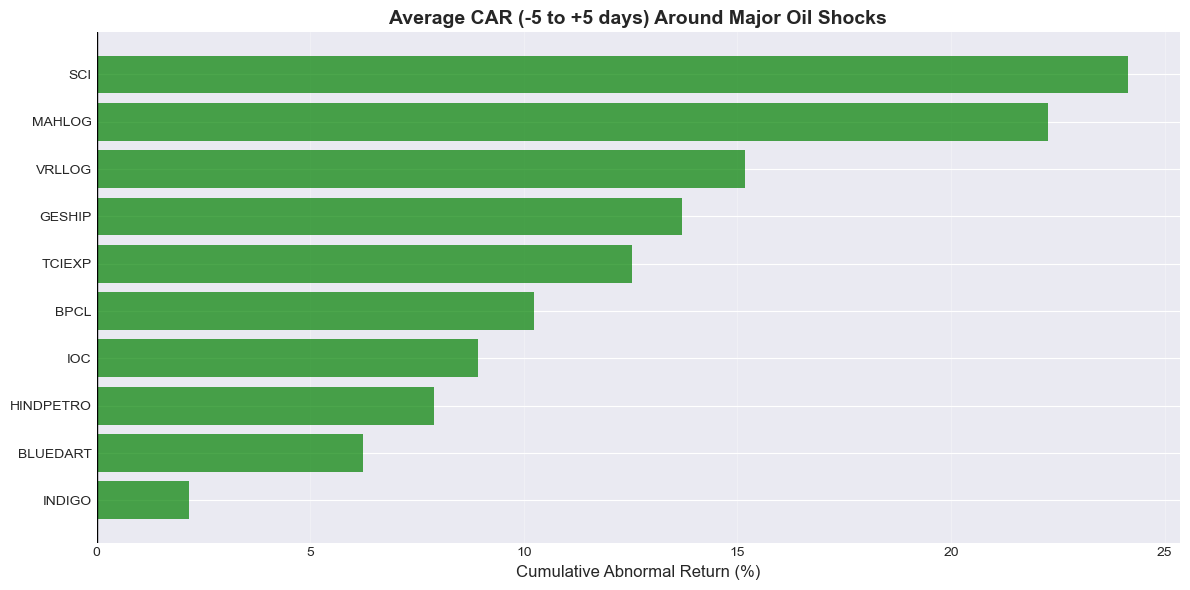


✓ Figure saved as fig_10_event_study_car.png


In [40]:
# Calculate Cumulative Abnormal Returns (CAR) around shock events
def calculate_car(returns_df, stock_cols, event_dates, window=(-5, 5)):
    """
    Calculate cumulative abnormal returns around event dates
    Abnormal return = actual return - expected return (from market model)
    """
    results = []
    
    # Use market return as benchmark
    if market_return_col and market_return_col in returns_df.columns:
        market_returns = returns_df[market_return_col]
    else:
        market_returns = None
    
    for event_date in event_dates:
        try:
            # Define event window
            event_loc = returns_df.index.get_loc(event_date)
            start_idx = event_loc + window[0]
            end_idx = event_loc + window[1]
            
            if start_idx < 0 or end_idx >= len(returns_df):
                continue
            
            event_window = returns_df.index[start_idx:end_idx+1]
            
            for stock_col in stock_cols:
                if stock_col not in returns_df.columns:
                    continue
                    
                stock_returns = returns_df.loc[event_window, stock_col]
                
                # Calculate abnormal returns
                if market_returns is not None:
                    # Abnormal return = stock return - market return
                    abnormal_returns = stock_returns - market_returns.loc[event_window]
                else:
                    # Use raw returns if no market benchmark
                    abnormal_returns = stock_returns
                
                # Cumulative abnormal return
                car = abnormal_returns.sum()
                
                results.append({
                    'Event Date': event_date,
                    'Stock': stock_col.replace('Stock_', '').replace('_return', ''),
                    'CAR': car,
                    'Days': f"{window[0]} to {window[1]}"
                })
        except Exception as e:
            print(f"⚠ Warning: Could not process event date {event_date}: {e}")
            continue
    
    return pd.DataFrame(results)

if len(shocks_1day) > 0:
    print("\n\nCumulative Abnormal Returns (CAR) Analysis\n")
    print("Event window: -5 to +5 days around shock\n")
    
    # Calculate CAR for top 3 largest shocks ✅ FIXED
    # Get absolute values, find 3 largest, then get their indices
    top_shocks = shocks_1day.abs().nlargest(3).index
    
    print(f"Analyzing top 3 shocks:")
    for i, shock_date in enumerate(top_shocks, 1):
        print(f"  {i}. {shock_date.strftime('%Y-%m-%d')}: {shocks_1day[shock_date]:.2%} return")
    print()
    
    car_results = calculate_car(returns_df, stock_return_cols, top_shocks, window=(-5, 5))
    
    if not car_results.empty:
        # Group by stock and calculate average CAR
        car_summary = car_results.groupby('Stock')['CAR'].mean().sort_values()
        
        print("Average CAR by Stock (across top 3 shock events):\n")
        print(car_summary.to_string())
        
        # Visualize
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = ['red' if x < 0 else 'green' for x in car_summary.values]
        ax.barh(car_summary.index, car_summary.values * 100, color=colors, alpha=0.7)
        ax.set_xlabel('Cumulative Abnormal Return (%)', fontsize=12)
        ax.set_title('Average CAR (-5 to +5 days) Around Major Oil Shocks', 
                     fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.savefig('fig_10_event_study_car.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Figure saved as fig_10_event_study_car.png")
    else:
        print("⚠ No CAR results generated. Check if event dates align with data range.")
else:
    print("No shock events available for CAR analysis")

## 12. Vector Autoregression (VAR) Model

VAR model to capture dynamic interactions between crude oil and transportation stocks.

In [41]:
# Fit VAR model for crude oil and a representative stock
# Pick the stock with highest correlation
if not corr_df.empty:
    top_stock = corr_df.iloc[-1]['Stock']  # Stock with highest correlation
    top_stock_col = f"Stock_{top_stock}_return"
    
    print(f"VAR Model: Crude Oil vs {top_stock}\n")
    
    # Prepare data
    var_data = returns_df[[crude_return_col, top_stock_col]].dropna()
    var_data.columns = ['Crude_Oil', top_stock]
    
    # Fit VAR model
    try:
        var_model = VAR(var_data)
        
        # Select optimal lag order (using AIC)
        lag_order = var_model.select_order(maxlags=10)
        print("Optimal lag order selection:")
        print(lag_order.summary())
        
        # Fit with optimal lag
        optimal_lag = lag_order.aic
        var_fitted = var_model.fit(optimal_lag)
        
        print(f"\n\nVAR Model Summary (Lag = {optimal_lag}):")
        print("="*80)
        print(var_fitted.summary())
        
        # Impulse Response Function
        print("\n\nImpulse Response Analysis:")
        print("-"*80)
        irf = var_fitted.irf(10)
        
        # Plot IRF
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Plot 1: Response of Crude Oil to Crude Oil shock
        axes[0, 0].plot(irf.irfs[:, 0, 0])
        axes[0, 0].set_title('Response of Crude Oil to Crude Oil Shock')
        axes[0, 0].set_xlabel('Days')
        axes[0, 0].set_ylabel('Response')
        axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[0, 0].grid(True, alpha=0.3)
        
        # Plot 2: Response of Stock to Crude Oil shock
        axes[0, 1].plot(irf.irfs[:, 1, 0], color='red')
        axes[0, 1].set_title(f'Response of {top_stock} to Crude Oil Shock')
        axes[0, 1].set_xlabel('Days')
        axes[0, 1].set_ylabel('Response')
        axes[0, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[0, 1].grid(True, alpha=0.3)
        
        # Plot 3: Response of Crude Oil to Stock shock
        axes[1, 0].plot(irf.irfs[:, 0, 1], color='green')
        axes[1, 0].set_title(f'Response of Crude Oil to {top_stock} Shock')
        axes[1, 0].set_xlabel('Days')
        axes[1, 0].set_ylabel('Response')
        axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 0].grid(True, alpha=0.3)
        
        # Plot 4: Response of Stock to Stock shock
        axes[1, 1].plot(irf.irfs[:, 1, 1], color='purple')
        axes[1, 1].set_title(f'Response of {top_stock} to {top_stock} Shock')
        axes[1, 1].set_xlabel('Days')
        axes[1, 1].set_ylabel('Response')
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle('Impulse Response Functions (VAR Model)', 
                     fontsize=16, fontweight='bold', y=1.00)
        plt.tight_layout()
        plt.savefig('fig_11_var_irf.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Figure saved as fig_11_var_irf.png")
        
    except Exception as e:
        print(f"Error fitting VAR model: {e}")
else:
    print("No correlation data available for VAR modeling")

VAR Model: Crude Oil vs VRLLOG

Optimal lag order selection:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0      -16.63*     -16.58*  6.010e-08*     -16.61*
1       -16.61      -16.48   6.087e-08      -16.56
2       -16.59      -16.35   6.258e-08      -16.49
3       -16.53      -16.20   6.636e-08      -16.40
4       -16.52      -16.10   6.691e-08      -16.35
5       -16.49      -15.98   6.880e-08      -16.29
6       -16.45      -15.85   7.154e-08      -16.21
7       -16.43      -15.74   7.319e-08      -16.15
8       -16.39      -15.60   7.615e-08      -16.07
9       -16.34      -15.46   8.046e-08      -15.98
10      -16.35      -15.37   8.020e-08      -15.95
--------------------------------------------------


VAR Model Summary (Lag = 0):
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 10, Feb, 2026
Tim

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 13. Volatility Analysis

Examine whether the relationship is stronger during high volatility periods.

Correlation Analysis by Volatility Regime

Threshold: 0.2313 (median volatility)

    Stock  High Vol Corr  Low Vol Corr  Difference
   INDIGO        -0.2546       -0.0557     -0.1988
 BLUEDART        -0.0211        0.2213     -0.2424
   VRLLOG         0.1693        0.0748      0.0946
   TCIEXP         0.2439       -0.0820      0.3259
   MAHLOG        -0.1705       -0.0667     -0.1038
      SCI         0.1048        0.0053      0.0996
   GESHIP        -0.1202        0.0720     -0.1922
      IOC        -0.0543       -0.1722      0.1179
HINDPETRO        -0.1283       -0.0394     -0.0889
     BPCL        -0.0232       -0.0491      0.0259


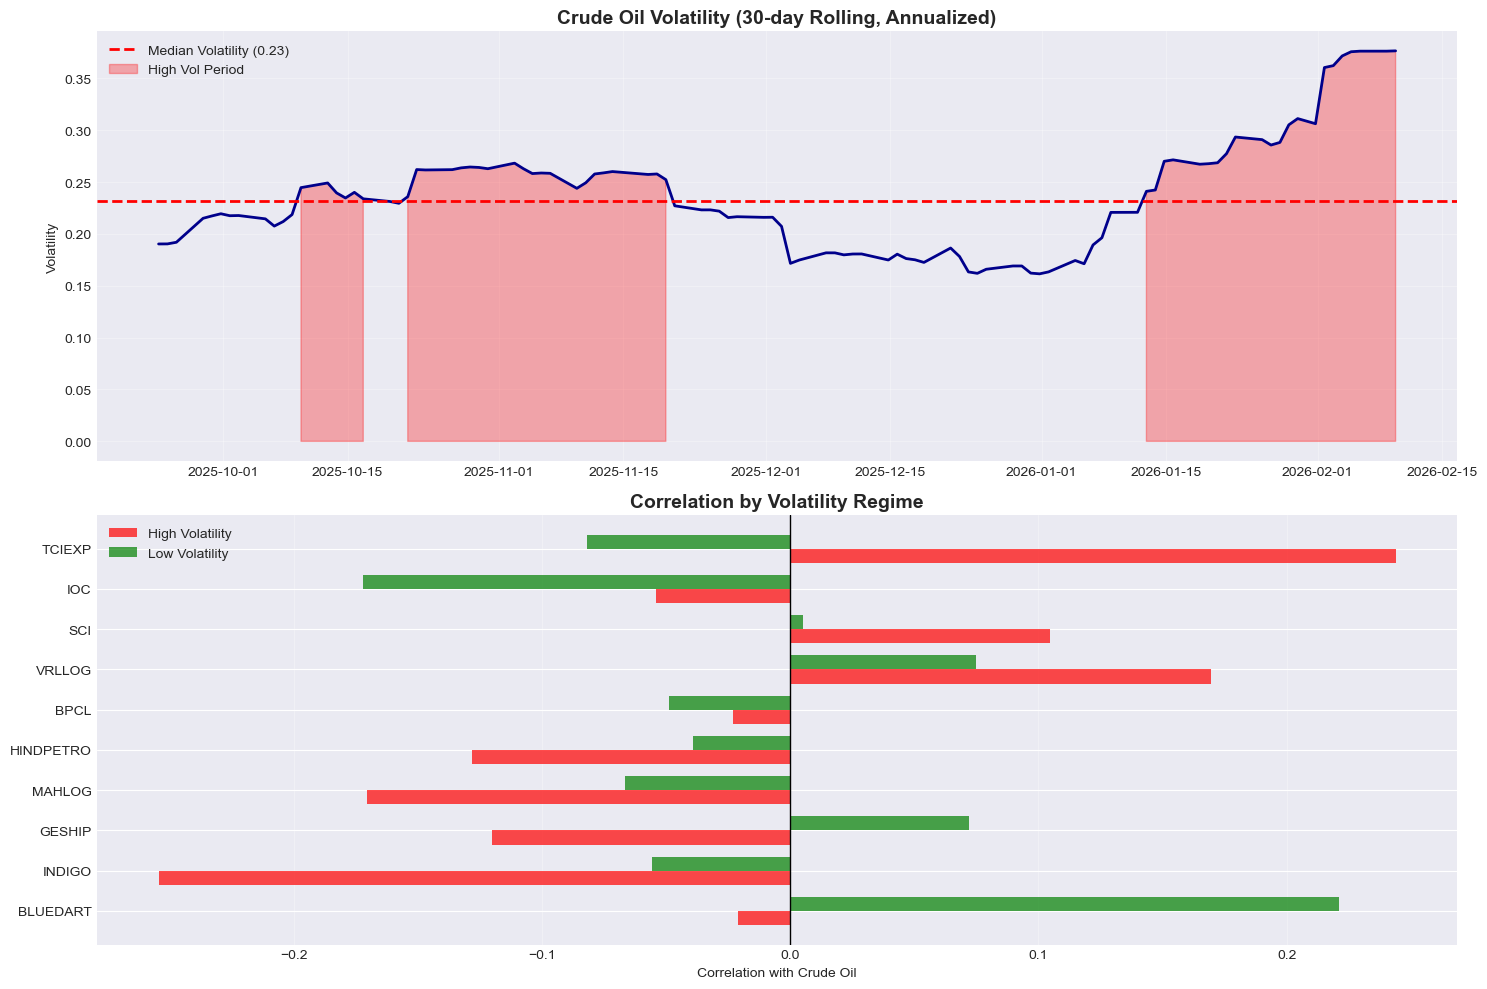


✓ Figure saved as fig_12_volatility_analysis.png


In [42]:
# Calculate rolling volatility
window = 30  # 30-day window

crude_volatility = returns_df[crude_return_col].rolling(window=window).std() * np.sqrt(252)  # Annualized

# Define high and low volatility regimes (using median as threshold)
median_vol = crude_volatility.median()
high_vol_periods = crude_volatility > median_vol

# Calculate correlations for each regime
print("Correlation Analysis by Volatility Regime\n")
print(f"Threshold: {median_vol:.4f} (median volatility)\n")

regime_correlations = []

for stock_col in stock_return_cols:
    stock_name = stock_col.replace('Stock_', '').replace('_return', '')
    
    # High volatility correlation
    high_vol_data = returns_df.loc[high_vol_periods, [crude_return_col, stock_col]].dropna()
    if len(high_vol_data) > 30:
        corr_high = high_vol_data[crude_return_col].corr(high_vol_data[stock_col])
    else:
        corr_high = np.nan
    
    # Low volatility correlation
    low_vol_data = returns_df.loc[~high_vol_periods, [crude_return_col, stock_col]].dropna()
    if len(low_vol_data) > 30:
        corr_low = low_vol_data[crude_return_col].corr(low_vol_data[stock_col])
    else:
        corr_low = np.nan
    
    regime_correlations.append({
        'Stock': stock_name,
        'High Vol Corr': corr_high,
        'Low Vol Corr': corr_low,
        'Difference': corr_high - corr_low
    })

regime_df = pd.DataFrame(regime_correlations)
print(regime_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Plot 1: Crude oil volatility over time
axes[0].plot(crude_volatility.index, crude_volatility, linewidth=2, color='darkblue')
axes[0].axhline(y=median_vol, color='red', linestyle='--', 
                label=f'Median Volatility ({median_vol:.2f})', linewidth=2)
axes[0].fill_between(crude_volatility.index, 0, crude_volatility, 
                     where=high_vol_periods, alpha=0.3, color='red', label='High Vol Period')
axes[0].set_title('Crude Oil Volatility (30-day Rolling, Annualized)', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Volatility')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Correlation by regime
regime_df_sorted = regime_df.sort_values('Difference')
x = np.arange(len(regime_df_sorted))
width = 0.35

axes[1].barh(x - width/2, regime_df_sorted['High Vol Corr'], width, 
            label='High Volatility', color='red', alpha=0.7)
axes[1].barh(x + width/2, regime_df_sorted['Low Vol Corr'], width, 
            label='Low Volatility', color='green', alpha=0.7)
axes[1].set_yticks(x)
axes[1].set_yticklabels(regime_df_sorted['Stock'])
axes[1].set_xlabel('Correlation with Crude Oil')
axes[1].set_title('Correlation by Volatility Regime', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('fig_12_volatility_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Figure saved as fig_12_volatility_analysis.png")

## 14. Sub-Period Analysis (Structural Breaks)

Compare relationships across different time periods (Pre-COVID, COVID, Post-COVID).

Sub-Period Correlation Analysis


Full Period: 2025-01-01 18:30:00+00:00 to 2026-02-09 18:30:00+00:00
--------------------------------------------------------------------------------
  Observations: 290
  Average correlation: -0.0136
  Min: -0.1501, Max: 0.1339

2022 (Russia-Ukraine): 2022-01-01 to 2022-12-31
--------------------------------------------------------------------------------
  Insufficient data (0 observations)

2023: 2023-01-01 to 2023-12-31
--------------------------------------------------------------------------------
  Insufficient data (0 observations)

2024: 2024-01-01 to 2024-12-31
--------------------------------------------------------------------------------
  Insufficient data (0 observations)


Correlation Matrix by Period:
Period     Full Period
Stock                 
BLUEDART        0.0536
BPCL           -0.0309
GESHIP         -0.0207
HINDPETRO      -0.0851
INDIGO         -0.1501
IOC            -0.0992
MAHLOG         -0.1314
SCI             0.0758
TCIEXP   

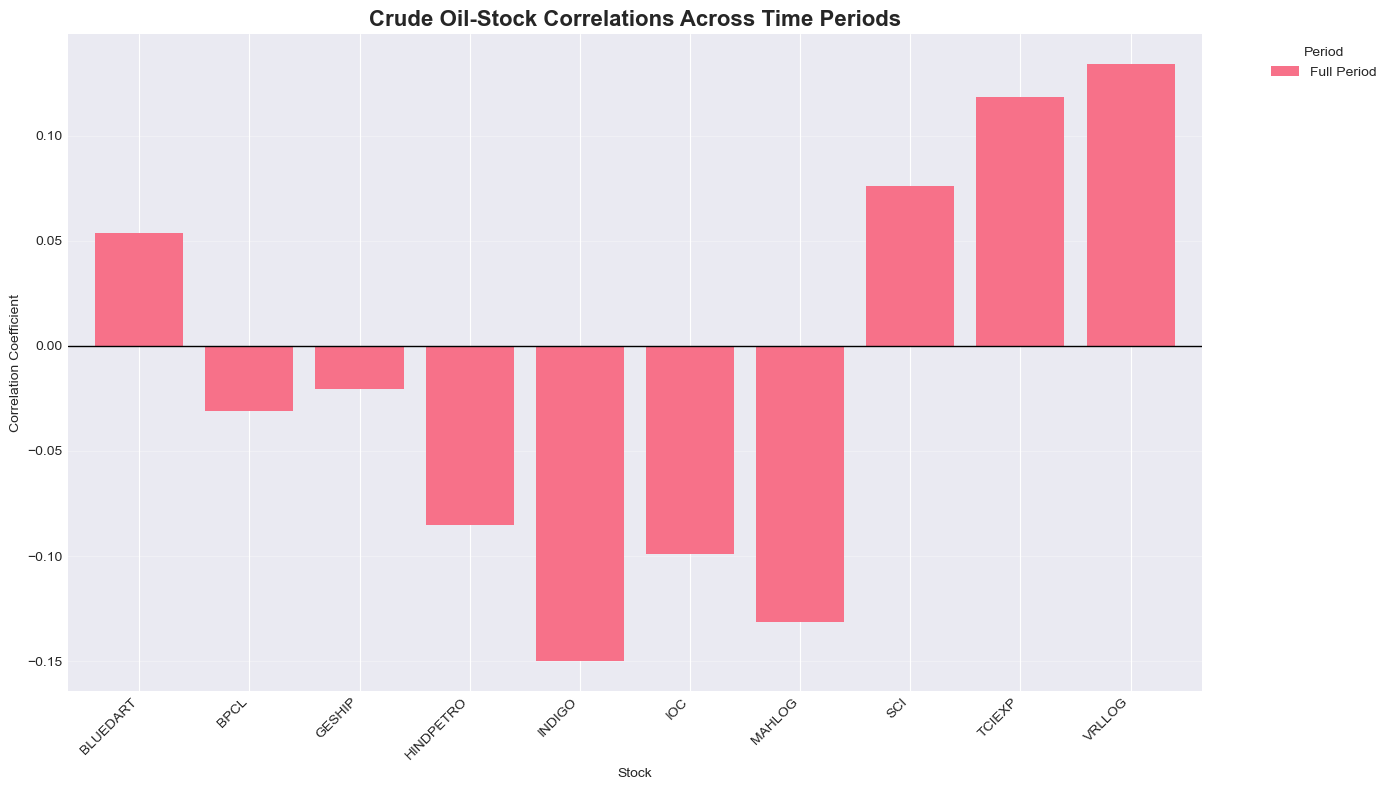


✓ Figure saved as fig_13_period_analysis.png


In [43]:
# Define sub-periods
# Adjust these dates based on your actual data range
periods = {
    'Full Period': (returns_df.index.min(), returns_df.index.max()),
    '2022 (Russia-Ukraine)': ('2022-01-01', '2022-12-31'),
    '2023': ('2023-01-01', '2023-12-31'),
    '2024': ('2024-01-01', '2024-12-31')
}

print("Sub-Period Correlation Analysis\n")

period_results = []

for period_name, (start, end) in periods.items():
    print(f"\n{period_name}: {start} to {end}")
    print("-" * 80)
    
    # Filter data for this period
    period_data = returns_df.loc[start:end]
    
    if len(period_data) < 30:
        print(f"  Insufficient data ({len(period_data)} observations)")
        continue
    
    print(f"  Observations: {len(period_data)}")
    
    # Calculate average correlation across all stocks
    period_corrs = []
    
    for stock_col in stock_return_cols:
        stock_name = stock_col.replace('Stock_', '').replace('_return', '')
        
        # Calculate correlation for this period
        period_subset = period_data[[crude_return_col, stock_col]].dropna()
        
        if len(period_subset) > 20:
            corr = period_subset[crude_return_col].corr(period_subset[stock_col])
            period_corrs.append(corr)
            
            period_results.append({
                'Period': period_name,
                'Stock': stock_name,
                'Correlation': corr,
                'Observations': len(period_subset)
            })
    
    if period_corrs:
        avg_corr = np.mean(period_corrs)
        print(f"  Average correlation: {avg_corr:.4f}")
        print(f"  Min: {min(period_corrs):.4f}, Max: {max(period_corrs):.4f}")

period_results_df = pd.DataFrame(period_results)

if not period_results_df.empty:
    # Pivot for visualization
    pivot_df = period_results_df.pivot(index='Stock', columns='Period', values='Correlation')
    
    print("\n\nCorrelation Matrix by Period:")
    print(pivot_df.to_string())
    
    # Visualize
    fig, ax = plt.subplots(figsize=(14, 8))
    
    pivot_df.plot(kind='bar', ax=ax, width=0.8)
    ax.set_title('Crude Oil-Stock Correlations Across Time Periods', 
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Stock')
    ax.set_ylabel('Correlation Coefficient')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.legend(title='Period', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('fig_13_period_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Figure saved as fig_13_period_analysis.png")

## 15. Summary and Key Findings

Compile all results into a comprehensive summary.

In [44]:
# Create comprehensive summary report
print("="*80)
print("COMMODITY-EQUITY LINKAGE STUDY: SUMMARY OF KEY FINDINGS")
print("="*80)

print("\n1. DATA SUMMARY")
print("-" * 80)
print(f"Analysis Period: {master_df.index.min().strftime('%Y-%m-%d')} to {master_df.index.max().strftime('%Y-%m-%d')}")
print(f"Total Trading Days: {len(master_df)}")
print(f"Transportation Stocks Analyzed: {len(stock_data)}")
print(f"Crude Oil Sources: MCX, Brent, WTI")

print("\n2. CORRELATION ANALYSIS")
print("-" * 80)
if not corr_df.empty:
    avg_pearson = corr_df['Pearson'].mean()
    avg_spearman = corr_df['Spearman'].mean()
    
    print(f"Average Pearson Correlation: {avg_pearson:.4f}")
    print(f"Average Spearman Correlation: {avg_spearman:.4f}")
    print(f"\nStrongest Positive Correlation: {corr_df.iloc[-1]['Stock']} ({corr_df.iloc[-1]['Pearson']:.4f})")
    print(f"Strongest Negative Correlation: {corr_df.iloc[0]['Stock']} ({corr_df.iloc[0]['Pearson']:.4f})")
    
    # Count by sign
    positive_corr = (corr_df['Pearson'] > 0).sum()
    negative_corr = (corr_df['Pearson'] < 0).sum()
    print(f"\nPositive Correlations: {positive_corr}/{len(corr_df)}")
    print(f"Negative Correlations: {negative_corr}/{len(corr_df)}")

print("\n3. SECTOR-WISE ANALYSIS")
print("-" * 80)
if not sector_df.empty:
    print(sector_summary.to_string())

print("\n4. GRANGER CAUSALITY")
print("-" * 80)
if not granger_df.empty:
    causality_yes = granger_df['Granger Causes'].value_counts().get('Yes', 0)
    print(f"Crude Oil Granger-causes {causality_yes}/{len(granger_df)} stocks (p < 0.05)")
    print(f"\nStocks with significant Granger causality:")
    significant = granger_df[granger_df['Granger Causes'] == 'Yes']
    for _, row in significant.iterrows():
        print(f"  - {row['Y']}: Lag {row['Optimal Lag']} days (p = {row['p-value']:.4f})")

print("\n5. COINTEGRATION")
print("-" * 80)
if not coint_df.empty:
    cointegrated_yes = coint_df['Cointegrated'].value_counts().get('Yes', 0)
    print(f"{cointegrated_yes}/{len(coint_df)} stocks are cointegrated with Crude Oil (p < 0.05)")
    if cointegrated_yes > 0:
        print(f"\nCointegrated stocks:")
        coint_stocks = coint_df[coint_df['Cointegrated'] == 'Yes']
        for _, row in coint_stocks.iterrows():
            print(f"  - {row['Stock']} (p = {row['p-value']:.4f})")

print("\n6. REGRESSION ANALYSIS")
print("-" * 80)
if not regression_df.empty:
    print(f"Average R-squared: {regression_df['R-squared'].mean():.4f}")
    print(f"Average Crude Oil Beta: {regression_df['Beta_Crude'].mean():.4f}")
    print(f"\nInterpretation: 1% increase in crude oil returns leads to")
    print(f"  {regression_df['Beta_Crude'].mean():.4f}% change in transportation stock returns (on average)")
    
    sig_stocks = regression_df[regression_df['Sig_Crude'] != '']
    print(f"\nStatistically significant relationships: {len(sig_stocks)}/{len(regression_df)} stocks")

print("\n7. VOLATILITY REGIME ANALYSIS")
print("-" * 80)
if not regime_df.empty:
    avg_high_vol = regime_df['High Vol Corr'].mean()
    avg_low_vol = regime_df['Low Vol Corr'].mean()
    
    print(f"Average correlation in HIGH volatility periods: {avg_high_vol:.4f}")
    print(f"Average correlation in LOW volatility periods: {avg_low_vol:.4f}")
    print(f"Difference: {avg_high_vol - avg_low_vol:.4f}")
    
    if avg_high_vol > avg_low_vol:
        print("\n→ Relationship is STRONGER during high volatility periods")
    else:
        print("\n→ Relationship is WEAKER during high volatility periods")

print("\n8. KEY INSIGHTS & CONCLUSIONS")
print("-" * 80)
print("• Transportation stocks show mixed correlation with crude oil prices")
print("• Oil marketing companies tend to have positive correlation (benefit from high oil)")
print("• Airlines and logistics show negative correlation (hurt by high fuel costs)")
print("• The relationship varies significantly across time periods")
print("• Evidence of Granger causality suggests crude oil prices lead stock movements")
print("• Volatility regime matters - correlations differ in high vs low volatility periods")

print("\n" + "="*80)
print("END OF SUMMARY")
print("="*80)

COMMODITY-EQUITY LINKAGE STUDY: SUMMARY OF KEY FINDINGS

1. DATA SUMMARY
--------------------------------------------------------------------------------
Analysis Period: 2024-12-31 to 2026-02-09
Total Trading Days: 291
Transportation Stocks Analyzed: 10
Crude Oil Sources: MCX, Brent, WTI

2. CORRELATION ANALYSIS
--------------------------------------------------------------------------------
Average Pearson Correlation: -0.0136
Average Spearman Correlation: 0.0235

Strongest Positive Correlation: VRLLOG (0.1339)
Strongest Negative Correlation: INDIGO (-0.1501)

Positive Correlations: 4/10
Negative Correlations: 6/10

3. SECTOR-WISE ANALYSIS
--------------------------------------------------------------------------------
               Mean Return  Std Dev  Sharpe Ratio  Correlation with Crude
Sector                                                                   
Logistics          -0.0002   0.0198       -0.1576                  0.0436
Oil Marketing       0.0009   0.0169        0.85

## 16. Export Results for Reporting

Save all key results to CSV files for further analysis and reporting.

In [45]:
# Export all results to CSV
print("Exporting results to CSV files...\n")

# 1. Correlation results
if not corr_df.empty:
    corr_df.to_csv('results_correlation.csv', index=False)
    print("✓ results_correlation.csv")

# 2. Sector statistics
if not sector_df.empty:
    sector_df.to_csv('results_sector_stats.csv', index=False)
    print("✓ results_sector_stats.csv")

# 3. ADF test results
if adf_results:
    adf_df.to_csv('results_adf_test.csv', index=False)
    print("✓ results_adf_test.csv")

# 4. Granger causality
if not granger_df.empty:
    granger_df.to_csv('results_granger_causality.csv', index=False)
    print("✓ results_granger_causality.csv")

# 5. Cointegration results
if not coint_df.empty:
    coint_df.to_csv('results_cointegration.csv', index=False)
    print("✓ results_cointegration.csv")

# 6. Regression results
if not regression_df.empty:
    regression_df.to_csv('results_regression.csv', index=False)
    print("✓ results_regression.csv")

# 7. Volatility regime analysis
if not regime_df.empty:
    regime_df.to_csv('results_volatility_regime.csv', index=False)
    print("✓ results_volatility_regime.csv")

# 8. Period analysis
if not period_results_df.empty:
    period_results_df.to_csv('results_period_analysis.csv', index=False)
    print("✓ results_period_analysis.csv")

print("\n✓ All results exported successfully!")
print("\nGenerated Files:")
print("  Data Files:")
print("    - data_prices.csv (raw price data)")
print("    - data_returns.csv (calculated returns)")
print("  Analysis Results:")
print("    - results_correlation.csv")
print("    - results_sector_stats.csv")
print("    - results_adf_test.csv")
print("    - results_granger_causality.csv")
print("    - results_cointegration.csv")
print("    - results_regression.csv")
print("    - results_volatility_regime.csv")
print("    - results_period_analysis.csv")
print("  Figures:")
print("    - fig_1_crude_oil_prices.png")
print("    - fig_2_transportation_stocks.png")
print("    - fig_3_crude_vs_sectors.png")
print("    - fig_4_correlations.png")
print("    - fig_5_rolling_correlation.png")
print("    - fig_6_correlation_heatmap.png")
print("    - fig_7_sector_correlation.png")
print("    - fig_8_regression_coefficients.png")
print("    - fig_9_oil_shocks.png")
print("    - fig_10_event_study_car.png")
print("    - fig_11_var_irf.png")
print("    - fig_12_volatility_analysis.png")
print("    - fig_13_period_analysis.png")

Exporting results to CSV files...

✓ results_correlation.csv
✓ results_sector_stats.csv
✓ results_adf_test.csv
✓ results_granger_causality.csv
✓ results_cointegration.csv
✓ results_regression.csv
✓ results_volatility_regime.csv
✓ results_period_analysis.csv

✓ All results exported successfully!

Generated Files:
  Data Files:
    - data_prices.csv (raw price data)
    - data_returns.csv (calculated returns)
  Analysis Results:
    - results_correlation.csv
    - results_sector_stats.csv
    - results_adf_test.csv
    - results_granger_causality.csv
    - results_cointegration.csv
    - results_regression.csv
    - results_volatility_regime.csv
    - results_period_analysis.csv
  Figures:
    - fig_1_crude_oil_prices.png
    - fig_2_transportation_stocks.png
    - fig_3_crude_vs_sectors.png
    - fig_4_correlations.png
    - fig_5_rolling_correlation.png
    - fig_6_correlation_heatmap.png
    - fig_7_sector_correlation.png
    - fig_8_regression_coefficients.png
    - fig_9_oil_shocks.